## Simulazione fatta direttamente con numpy, stabilendo già partecipanti e vincitori alle auction, senza usare AuctionGym.

In [1]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def group_data(dir_path: str, iteration_drift: int = None) -> tuple[pd.DataFrame, pd.DataFrame] | tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern_algo = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    pattern_opt = r'opt_exp_results_run_(\d+)'
    pattern_opt_after = r'opt_exp_results_after_drift_run_(\d+)'
    pattern_opt_before = r'opt_exp_results_before_drift_run_(\d+)'
    
    # Verifica quale tipo di file ottimali sono presenti
    has_simple_opt = any(re.search(pattern_opt, file) for file in files_to_read)
    has_drift_opt = any(re.search(pattern_opt_after, file) for file in files_to_read) and \
                    any(re.search(pattern_opt_before, file) for file in files_to_read)
    
    if has_simple_opt and has_drift_opt:
        raise ValueError("Non possono essere presenti entrambi i tipi di file ottimali")
    
    algo_results = pd.DataFrame()
    for file in files_to_read:
        match_algo = re.search(pattern_algo, file)
        if match_algo:
            num_run = int(match_algo.group(1))
            soglia_ctr = float(match_algo.group(2))
            alpha = float(match_algo.group(3))
            
            curr_results = pd.read_csv(dir_path + file)
            curr_results['Run'] = num_run
            curr_results['soglia_ctr'] = soglia_ctr
            curr_results['alpha'] = alpha
            algo_results = pd.concat([algo_results, curr_results])

    # Group algorithm results
    grouped_results_run_iter = algo_results.groupby(['soglia_ctr','alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'publisher':'nunique'}) \
        .reset_index()
    grouped_results_run_iter['ctr'] = grouped_results_run_iter['clicks'] / grouped_results_run_iter['impressions']

    if has_simple_opt:
        # Gestione caso file ottimali semplici
        optimum_results = pd.DataFrame()
        for file in files_to_read:
            match_optimum = re.search(pattern_opt, file)
            if match_optimum:
                num_run = int(match_optimum.group(1))
                curr_results = pd.read_csv(dir_path + file)
                curr_results['Run'] = num_run
                optimum_results = pd.concat([optimum_results, curr_results])
        
        grouped_optimal_results_run = optimum_results.groupby(['Run']) \
            .agg({'clicks': 'sum', 'impressions': 'sum', 'publisher': 'nunique'}) \
            .reset_index()
        grouped_optimal_results_run['ctr'] = grouped_optimal_results_run['clicks'] / grouped_optimal_results_run['impressions']

        grouped_results_run_iter = pd.merge(grouped_results_run_iter, grouped_optimal_results_run, on='Run', suffixes=('', '_optimal'))
        grouped_results_run_iter['regret_clicks'] = grouped_results_run_iter['clicks_optimal'] - grouped_results_run_iter['clicks']

        grouped_results = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).mean().reset_index()

        # Calcolo intervalli di confidenza per metriche standard
        for metric in ['clicks', 'impressions', 'ctr', 'publisher', 'regret_clicks']:
            grouped_results[f'{metric}_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()[metric]
            grouped_results[f'{metric}_ci'] = 1.96 * grouped_results[f'{metric}_std'] / np.sqrt(
                grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()[metric])

        # Risultati ottimali medi
        grouped_opt_results = grouped_optimal_results_run.mean().to_frame().T
        for metric in ['clicks', 'impressions', 'ctr', 'publisher']:
            grouped_opt_results[f'{metric}_std'] = grouped_optimal_results_run.std()[metric]
            grouped_opt_results[f'{metric}_ci'] = 1.96 * grouped_opt_results[f'{metric}_std'] / np.sqrt(len(grouped_optimal_results_run))

        return grouped_results, grouped_opt_results
    
    else:
        # Gestione caso file ottimali before/after drift
        optimum_results_before = pd.DataFrame()
        optimum_results_after = pd.DataFrame()
        
        for file in files_to_read:
            match_before = re.search(pattern_opt_before, file)
            match_after = re.search(pattern_opt_after, file)
            
            if match_before:
                num_run = int(match_before.group(1))
                curr_results = pd.read_csv(dir_path + file)
                curr_results['Run'] = num_run
                optimum_results_before = pd.concat([optimum_results_before, curr_results])
            elif match_after:
                num_run = int(match_after.group(1))
                curr_results = pd.read_csv(dir_path + file)
                curr_results['Run'] = num_run
                optimum_results_after = pd.concat([optimum_results_after, curr_results])

        grouped_optimal_before = optimum_results_before.groupby(['Run']) \
            .agg({'clicks': 'sum', 'impressions': 'sum', 'publisher': 'nunique'}) \
            .reset_index()
        grouped_optimal_before['ctr'] = grouped_optimal_before['clicks'] / grouped_optimal_before['impressions']

        grouped_optimal_after = optimum_results_after.groupby(['Run']) \
            .agg({'clicks': 'sum', 'impressions': 'sum', 'publisher': 'nunique'}) \
            .reset_index()
        grouped_optimal_after['ctr'] = grouped_optimal_after['clicks'] / grouped_optimal_after['impressions']

        grouped_results_run_iter = pd.merge(grouped_results_run_iter, grouped_optimal_before, on='Run', suffixes=('', '_optimal_before'))
        grouped_results_run_iter = pd.merge(grouped_results_run_iter, grouped_optimal_after, on='Run', suffixes=('', '_optimal_after'))

        grouped_results_run_iter['regret_clicks_before'] = grouped_results_run_iter['clicks_optimal_before'] - grouped_results_run_iter['clicks']
        grouped_results_run_iter['regret_clicks_after'] = grouped_results_run_iter['clicks_optimal_after'] - grouped_results_run_iter['clicks']
        grouped_results_run_iter['regret_clicks'] = np.where(grouped_results_run_iter['Iteration'] < iteration_drift, grouped_results_run_iter['regret_clicks_before'], grouped_results_run_iter['regret_clicks_after'])

        grouped_results = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).mean().reset_index()

        # Calcolo intervalli di confidenza per tutte le metriche
        metrics = ['clicks', 'impressions', 'ctr', 'publisher', 
                  'regret_clicks_before', 'regret_clicks_after']
        
        for metric in metrics:
            grouped_results[f'{metric}_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()[metric]
            grouped_results[f'{metric}_ci'] = 1.96 * grouped_results[f'{metric}_std'] / np.sqrt(
                grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()[metric])
        
        grouped_results['regret_clicks_ci'] = np.where(grouped_results['Iteration'] < iteration_drift, grouped_results['regret_clicks_before_ci'], grouped_results['regret_clicks_after_ci'])

        # Risultati ottimali medi before/after
        grouped_opt_before = grouped_optimal_before.mean().to_frame().T
        grouped_opt_after = grouped_optimal_after.mean().to_frame().T
        
        for df, source_df in [(grouped_opt_before, grouped_optimal_before), 
                             (grouped_opt_after, grouped_optimal_after)]:
            for metric in ['clicks', 'impressions', 'ctr', 'publisher']:
                df[f'{metric}_std'] = source_df.std()[metric]
                df[f'{metric}_ci'] = 1.96 * df[f'{metric}_std'] / np.sqrt(len(source_df))

        return grouped_results, grouped_opt_before, grouped_opt_after

In [3]:
def group_data_sw(dir_path: str, iteration_drift: int = None):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)_ws_(\d+)'
    pattern_after_drift = r'opt_exp_results_after_drift_run_(\d+)'
    pattern_before_drift = r'opt_exp_results_before_drift_run_(\d+)'
    results_after_drift = pd.DataFrame()
    results_before_drift = pd.DataFrame()
    results = pd.DataFrame()

    for file in files_to_read:
        match = re.search(pattern, file)
        match_after = re.search(pattern_after_drift, file)
        match_before = re.search(pattern_before_drift, file)

        if match:
            num_run = int(match.group(1))
            soglia_ctr = float(match.group(2))
            alpha = float(match.group(3))
            ws = int(match.group(4))
            
            curr_results = pd.read_csv(dir_path + file)
            curr_results['Run'] = num_run
            curr_results['soglia_ctr'] = soglia_ctr
            curr_results['alpha'] = alpha
            curr_results['ws'] = ws
            results = pd.concat([results, curr_results])

        elif match_after:
            num_run = int(match_after.group(1))
            curr_results = pd.read_csv(dir_path + file)
            curr_results['Run'] = num_run
            results_after_drift = pd.concat([results_after_drift, curr_results])
            
        elif match_before:
            num_run = int(match_before.group(1))
            curr_results = pd.read_csv(dir_path + file)
            curr_results['Run'] = num_run
            results_before_drift = pd.concat([results_before_drift, curr_results])

    # Group results by run and iteration
    grouped_results_run_iter = results.groupby(['soglia_ctr', 'ws', 'alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'publisher':'nunique'}) \
        .reset_index()
    grouped_results_run_iter['ctr'] = grouped_results_run_iter['clicks'] / grouped_results_run_iter['impressions']

    if not results_after_drift.empty and not results_before_drift.empty:
        # Group optimal results before drift
        grouped_optimal_before = results_before_drift.groupby(['Run']) \
            .agg({'clicks': 'sum', 'impressions': 'sum', 'publisher': 'nunique'}) \
            .reset_index()
        grouped_optimal_before['ctr'] = grouped_optimal_before['clicks'] / grouped_optimal_before['impressions']

        # Group optimal results after drift
        grouped_optimal_after = results_after_drift.groupby(['Run']) \
            .agg({'clicks': 'sum', 'impressions': 'sum', 'publisher': 'nunique'}) \
            .reset_index()
        grouped_optimal_after['ctr'] = grouped_optimal_after['clicks'] / grouped_optimal_after['impressions']

        # Merge optimal results with the algorithm results
        grouped_results_run_iter = pd.merge(grouped_results_run_iter, grouped_optimal_before, on='Run', suffixes=('', '_optimal_before'))
        grouped_results_run_iter = pd.merge(grouped_results_run_iter, grouped_optimal_after, on='Run', suffixes=('', '_optimal_after'))

        # Calculate regrets
        grouped_results_run_iter['regret_clicks_before'] = grouped_results_run_iter['clicks_optimal_before'] - grouped_results_run_iter['clicks']
        grouped_results_run_iter['regret_clicks_after'] = grouped_results_run_iter['clicks_optimal_after'] - grouped_results_run_iter['clicks']
        grouped_results_run_iter['regret_clicks'] = np.where(grouped_results_run_iter['Iteration'] < iteration_drift, grouped_results_run_iter['regret_clicks_before'], grouped_results_run_iter['regret_clicks_after'])

    # Average over runs for each iteration
    grouped_results = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).mean().reset_index()

    # Confidence intervals for base metrics
    for metric in ['clicks', 'impressions', 'ctr', 'publisher']:
        grouped_results[f'{metric}_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()[metric]
        grouped_results[f'{metric}_ci'] = 1.96 * grouped_results[f'{metric}_std'] / np.sqrt(
            grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()[metric])

    if not results_after_drift.empty and not results_before_drift.empty:
        # Confidence intervals for regret metrics
        for metric in ['regret_clicks_before', 'regret_clicks_after']:
            grouped_results[f'{metric}_std'] = grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).std().reset_index()[metric]
            grouped_results[f'{metric}_ci'] = 1.96 * grouped_results[f'{metric}_std'] / np.sqrt(
                grouped_results_run_iter.groupby(['soglia_ctr', 'ws', 'alpha', 'Iteration']).count().reset_index()['clicks'])
            
        grouped_results['regret_clicks_ci'] = np.where(grouped_results['Iteration'] < iteration_drift, grouped_results['regret_clicks_before_ci'], grouped_results['regret_clicks_after_ci'])

        # Calculate mean optimal values
        grouped_opt_before = grouped_optimal_before.mean().to_frame().T
        grouped_opt_after = grouped_optimal_after.mean().to_frame().T

        # Add confidence intervals for optimal values
        for df in [grouped_opt_before, grouped_opt_after]:
            for metric in ['clicks', 'impressions', 'ctr', 'publisher']:
                df[f'{metric}_std'] = grouped_optimal_before.std()[metric]
                df[f'{metric}_ci'] = 1.96 * df[f'{metric}_std'] / np.sqrt(len(grouped_optimal_before))
    
    if not results_after_drift.empty and not results_before_drift.empty:
        return grouped_results, grouped_opt_before, grouped_opt_after
    else:
        return grouped_results

In [4]:
def plot_clicks(ax, model_data, model):
    ax.plot(model_data['Iteration'].to_numpy(), model_data['clicks'].to_numpy(), label=f'{model}')
    if 'clicks_ci' in model_data.columns:
        ax.fill_between(model_data['Iteration'].to_numpy(), 
                        model_data['clicks'].to_numpy() -  model_data['clicks_ci'].to_numpy(), 
                        model_data['clicks'].to_numpy() +  model_data['clicks_ci'].to_numpy(), 
                        alpha=0.5)
    ax.grid(color="gray", linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
    ax.set_ylabel('cl')

def plot_ctr(ax, model_data, model):
    ax.plot(model_data['Iteration'].to_numpy(), model_data['ctr'].to_numpy()*100, label=f'{model}')
    if 'ctr_ci' in model_data.columns:
        ax.fill_between(model_data['Iteration'].to_numpy(), 
                        (model_data['ctr'].to_numpy() -  model_data['ctr_ci'].to_numpy())*100, 
                        (model_data['ctr'].to_numpy() +  model_data['ctr_ci'].to_numpy())*100, 
                        alpha=0.5)
    ax.grid(color="gray", linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
    ax.set_ylabel('CTR %')
    
def plot_click_ctr(gr_res_models: dict, iteration: int = 1, iteration_drift: int = None, alpha_inlcude_list: list[float] = None, save_path: str = None):
    """Plot on the same row two graphs: one with the clicks and one with the CTR.

    Parameters
    ----------
    gr_res_models : dict
        _description_
    iteration : int, optional
        _description_, by default 1
    target_ctr : float, optional
        _description_, by default 0.9
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

    for model, gr_res in gr_res_models.items():
        if model == 'opt' or model == 'Optimal after drift' or model == 'Optimal before drift':
            continue        
        if 'ws' in gr_res.columns:
            for ws in gr_res['ws'].unique():
                model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['ws'] == ws)]
                iteration_list = model_data['Iteration'].to_numpy()
                target_ctr = model_data['soglia_ctr'].unique()[0]
                plot_clicks(ax1, model_data, f'{model} ws={ws}')
                plot_ctr(ax2, model_data, f'{model} ws={ws}')
                ax2.set_xlabel('t (time)')
        else:
            model_data = gr_res[(gr_res['Iteration']>iteration)]
            alpha_list = model_data['alpha'].unique()
            if len(alpha_list) > 1:
                for alpha in alpha_list:
                    if alpha_inlcude_list and alpha not in alpha_inlcude_list:
                        continue
                    model_data_alpha = model_data[model_data['alpha'] == alpha]
                    iteration_list = model_data_alpha['Iteration'].to_numpy()
                    target_ctr = model_data_alpha['soglia_ctr'].unique()[0]
                    plot_clicks(ax1, model_data_alpha, f'{model} alpha={alpha}')
                    plot_ctr(ax2, model_data_alpha, f'{model} alpha={alpha}')
                    ax2.set_xlabel('t (time)')
            else:
                iteration_list = model_data['Iteration'].to_numpy()
                target_ctr = model_data['soglia_ctr'].unique()[0]
                plot_clicks(ax1, model_data, model)
                plot_ctr(ax2, model_data, model)
                ax2.set_xlabel('t (time)')

    if 'opt' in gr_res_models:
        opt_res = gr_res_models['opt']
        ax1.axhline(y=opt_res['clicks'].to_numpy(), color='r', linestyle='--', label=f'Optimal')
        if 'clicks_ci' in opt_res.columns:
            ax1.fill_between(iteration_list,
                            opt_res['clicks'].to_numpy() -  opt_res['clicks_ci'].to_numpy(), 
                            opt_res['clicks'].to_numpy() +  opt_res['clicks_ci'].to_numpy(), 
                            alpha=0.5)
    if 'Optimal after drift' in gr_res_models:
        opt_res = gr_res_models['Optimal after drift']
        ax1.plot((max(iteration, iteration_drift), iteration_list[-1]), (opt_res['clicks'], opt_res['clicks']), label=f'Optimum # of clicks', linestyle='--', color='r')
        if 'clicks_ci' in opt_res.columns:
            ax1.fill_between((max(iteration, iteration_drift), iteration_list[-1]),
                            opt_res['clicks'].to_numpy() -  opt_res['clicks_ci'].to_numpy(), 
                            opt_res['clicks'].to_numpy() +  opt_res['clicks_ci'].to_numpy(), 
                            alpha=0.5)
    if 'Optimal before drift' in gr_res_models and iteration < iteration_drift:
        opt_res = gr_res_models['Optimal before drift']
        ax1.plot((max(0,iteration), iteration_drift), (opt_res['clicks'], opt_res['clicks']), linestyle='--', color='r')
        if 'clicks_ci' in opt_res.columns:
            ax1.fill_between((max(0,iteration), iteration_drift),
                            opt_res['clicks'].to_numpy() -  opt_res['clicks_ci'].to_numpy(), 
                            opt_res['clicks'].to_numpy() +  opt_res['clicks_ci'].to_numpy(), 
                            alpha=0.5)
            
    if iteration_drift:
        ax1.axvline(x=iteration_drift, color='g', linestyle='--', label=f'Drift')
        ax2.axvline(x=iteration_drift, color='g', linestyle='--', label=f'Drift')

    # Target CTR
    ax2.axhline(y=target_ctr*100, color='r', linestyle='--', label=f'Target CTR')
    
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300)
    plt.show()

In [5]:
def plot_regret_clicks(ax, model_data, model):
    ax.plot(model_data['Iteration'].to_numpy(), model_data['regret_clicks'].to_numpy(), label=f'{model}')
    if 'regret_clicks_ci' in model_data.columns:
        ax.fill_between(model_data['Iteration'].to_numpy(), 
                        model_data['regret_clicks'].to_numpy() -  model_data['regret_clicks_ci'].to_numpy(), 
                        model_data['regret_clicks'].to_numpy() +  model_data['regret_clicks_ci'].to_numpy(), 
                        alpha=0.5)
    ax.grid(color="gray", linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
    ax.set_ylabel('Regret clicks')

def plot_regret_ctr(ax, model_data, model):
    ax.plot(model_data['Iteration'].to_numpy(), model_data['regret_ctr'].to_numpy()*100, label=f'{model}')
    if 'ctr_ci' in model_data.columns:
        ax.fill_between(model_data['Iteration'].to_numpy(), 
                        (model_data['regret_ctr'].to_numpy() -  model_data['regret_ctr_ci'].to_numpy())*100, 
                        (model_data['regret_ctr'].to_numpy() +  model_data['regret_ctr_ci'].to_numpy())*100, 
                        alpha=0.5)
    ax.grid(color="gray", linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
    ax.set_ylabel('Regret CTR')
    
def plot_regret_click_ctr(gr_res_models: dict, iteration: int = 1, iteration_drift: int = None, save_path: str = None):
    fig, (ax1) = plt.subplots(1, 1, figsize=(8, 5))

    for model, gr_res in gr_res_models.items():
        if model == 'opt' or model == 'Optimal after drift' or model == 'Optimal before drift':
            continue
        model_data = gr_res[(gr_res['Iteration']>iteration)]
        plot_regret_clicks(ax1, model_data, model)
        #plot_regret_ctr(ax2, model_data, model)
        ax1.set_xlabel('t (time)')
    
    if iteration_drift:
        ax1.axvline(x=iteration_drift, color='g', linestyle='--', label=f'Drift')
    
    ax1.legend()
    #ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300)
    plt.show()

### CTR = 67%

In [18]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_67_28_01_25_moreiter/'
cucb_results = group_data(cucb_exp_dir)
#cucb_opt_res = group_opt_data(cucb_exp_dir)

In [14]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_67_28_01_25_moreiter/'
linucb_results = group_data(linucb_exp_dir)
linucb_opt_res = group_opt_data(linucb_exp_dir)

In [19]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}

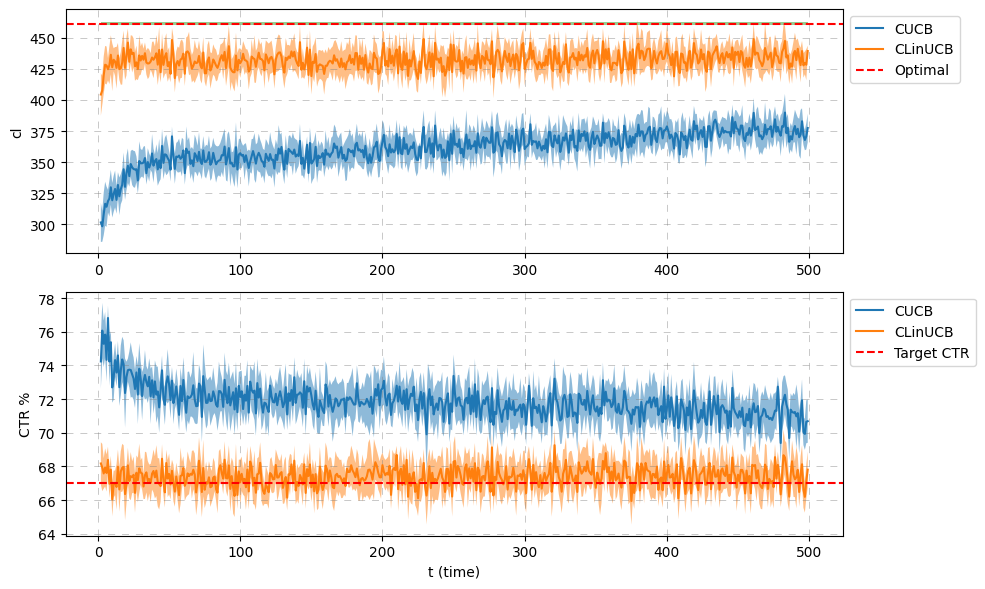

In [20]:
plot_click_ctr(models, iteration=1)

### CTR = 70%

In [8]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_7_28_01_25_moreiter/'
cucb_results = group_data(cucb_exp_dir)
cucb_opt_res = group_opt_data(cucb_exp_dir)

In [11]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_7_28_01_25_moreiter/'
linucb_results = group_data(linucb_exp_dir)
# linucb_opt_res = group_opt_data(linucb_exp_dir)

In [12]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': cucb_opt_res
}

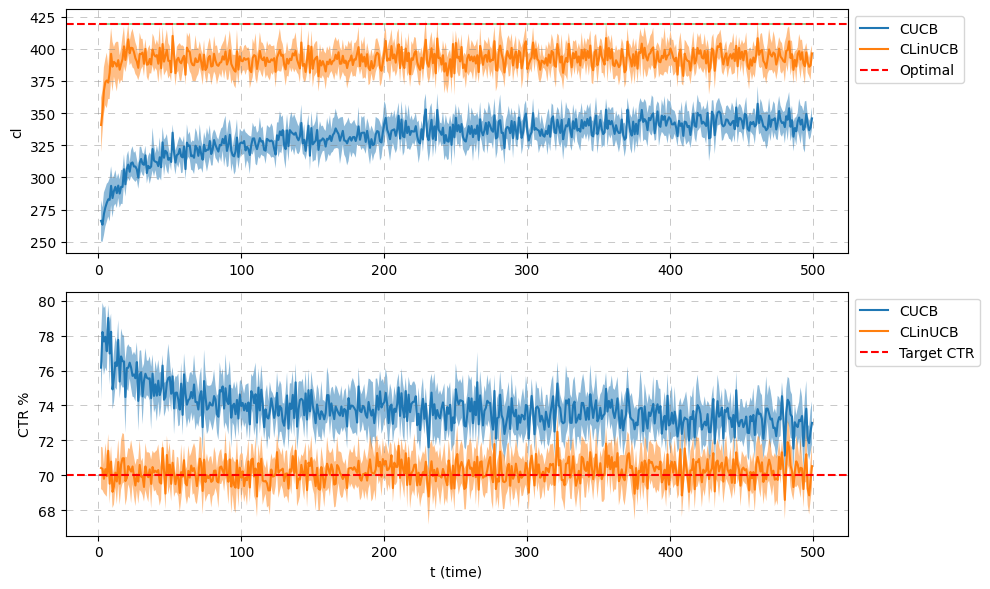

In [13]:
plot_click_ctr(models, iteration=1)

### CTR = 80%

In [25]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_8_28_01_25_moreiter/'
cucb_results = group_data(cucb_exp_dir)
#cucb_opt_res = group_opt_data(cucb_exp_dir)

In [22]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_8_28_01_25_moreiter/'
linucb_results = group_data(linucb_exp_dir)
linucb_opt_res = group_opt_data(linucb_exp_dir)

In [26]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}

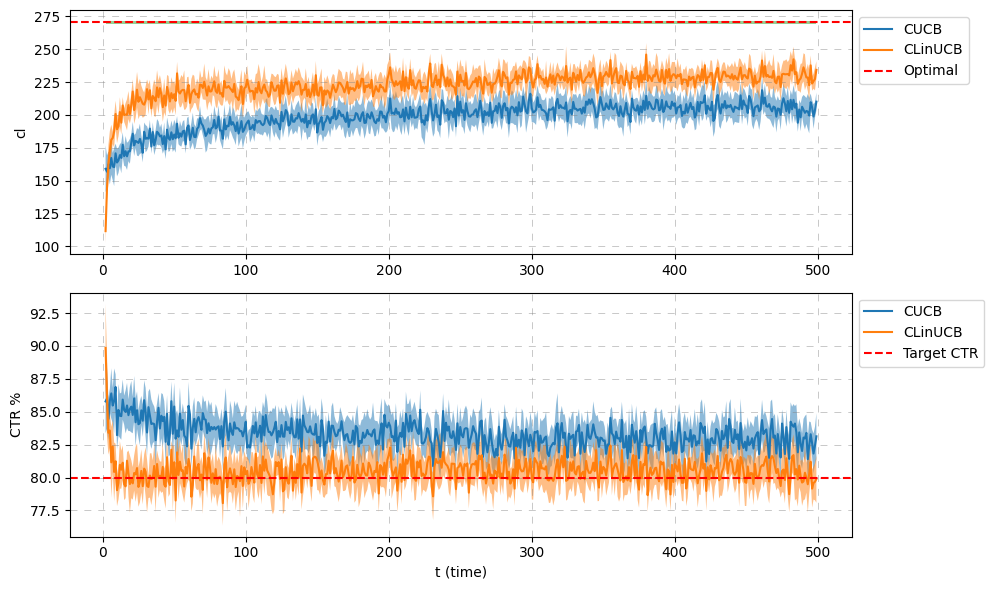

In [27]:
plot_click_ctr(models, iteration=1)

### CTR = 90%

In [29]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_9_28_01_25_moreiter/'
cucb_results = group_data(cucb_exp_dir)
# cucb_opt_res = group_opt_data(cucb_exp_dir)

In [32]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_9_28_01_25_moreiter/'
linucb_results = group_data(linucb_exp_dir)
linucb_opt_res = group_opt_data(linucb_exp_dir)

In [33]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}

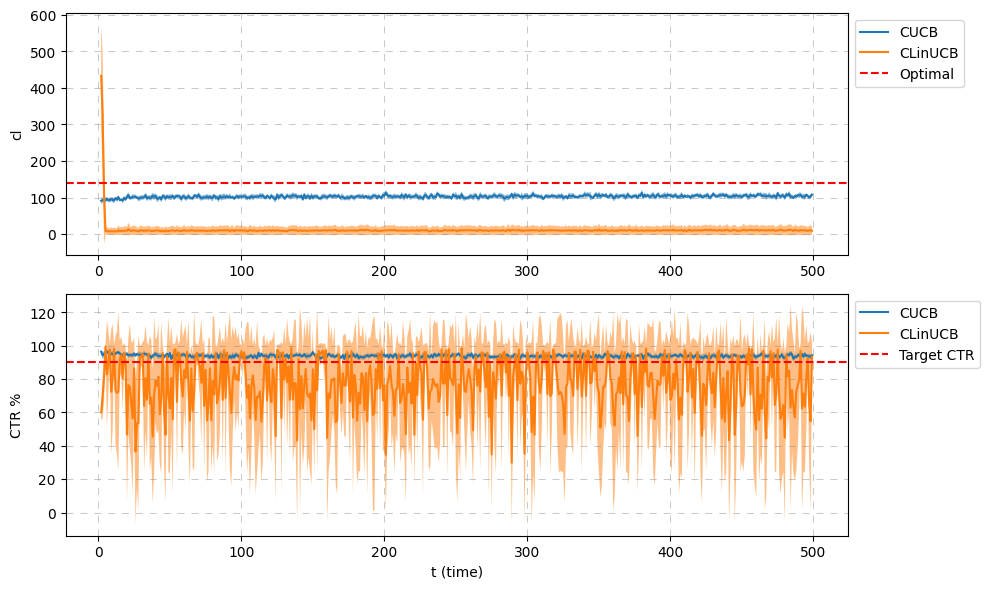

In [41]:
plot_click_ctr(models, iteration=1)

## SW

### CTR = 65%

In [51]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_drift_ctr_0_65_28_01_25_moreiter/'
cucb_results = group_data(cucb_exp_dir)

In [42]:
swlinucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swlinucb_rescaledtextemb_ctr_0_65_28_01_25_moreiter/'
swlinucb_results = group_data_sw(swlinucb_exp_dir)
swlinucb_opt_res_after_drift, swlinucb_opt_res_before_drift = group_opt_data_sw(swlinucb_exp_dir)

In [47]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_drift_rescaledtextemb_ctr_0_65_28_01_25_moreiter/'
linucb_results = group_data(linucb_exp_dir)

In [52]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results,
    'SW-CLinUCB': swlinucb_results,
    'Optimal after drift': swlinucb_opt_res_after_drift,
    'Optimal before drift': swlinucb_opt_res_before_drift
}

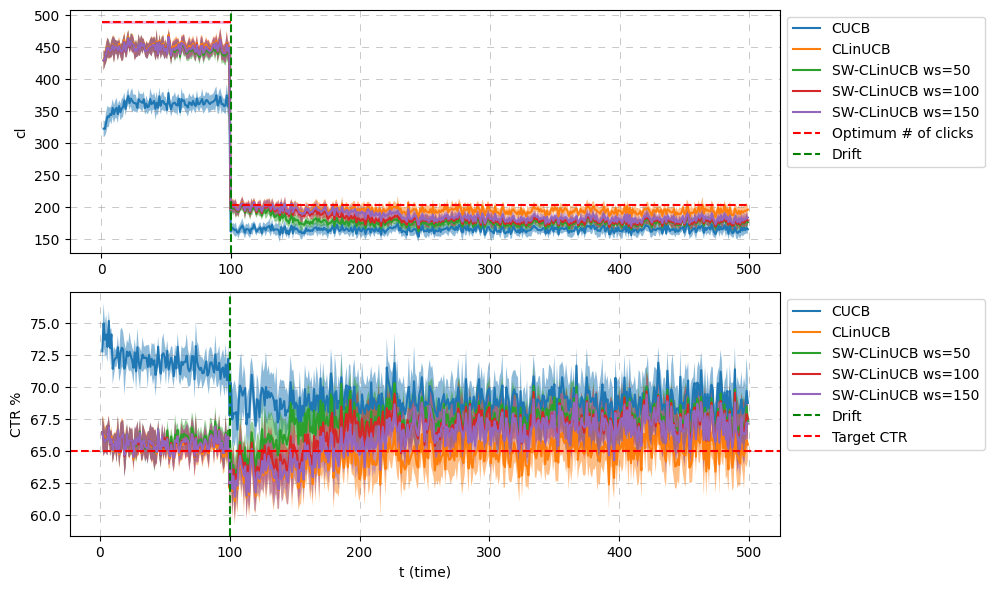

In [58]:
plot_click_ctr(models, iteration=1, iteration_drift=100)

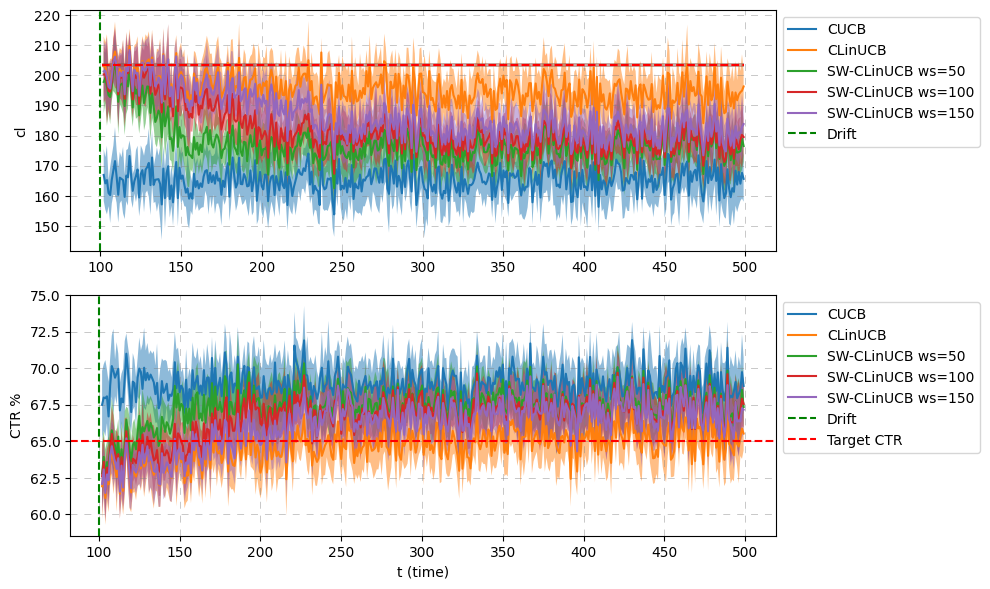

In [54]:
plot_click_ctr(models, iteration=101, iteration_drift=100)

### CTR = 75%

In [59]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_drift_ctr_0_75_28_01_25_moreiter/'
cucb_results = group_data(cucb_exp_dir)

In [63]:
swlinucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swlinucb_rescaledtextemb_ctr_0_75_28_01_25_moreiter/'
swlinucb_results = group_data_sw(swlinucb_exp_dir)
swlinucb_opt_res_after_drift, swlinucb_opt_res_before_drift = group_opt_data_sw(swlinucb_exp_dir)

In [67]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_drift_rescaledtextemb_ctr_0_75_28_01_25_moreiter/'
linucb_results = group_data(linucb_exp_dir)

In [68]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results,
    'SW-CLinUCB': swlinucb_results,
    'Optimal after drift': swlinucb_opt_res_after_drift,
    'Optimal before drift': swlinucb_opt_res_before_drift
}

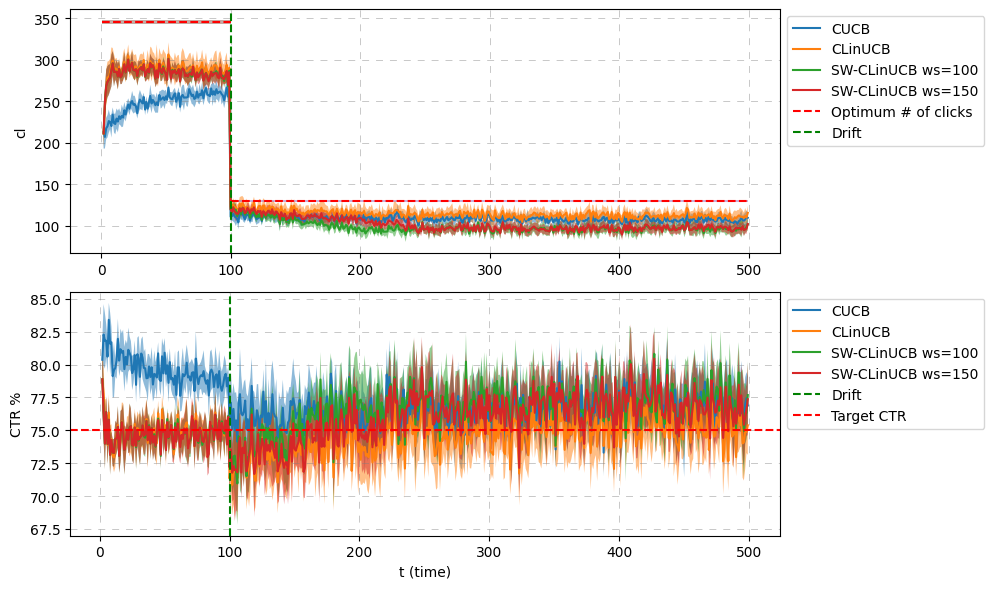

In [69]:
plot_click_ctr(models, iteration=1, iteration_drift=100)

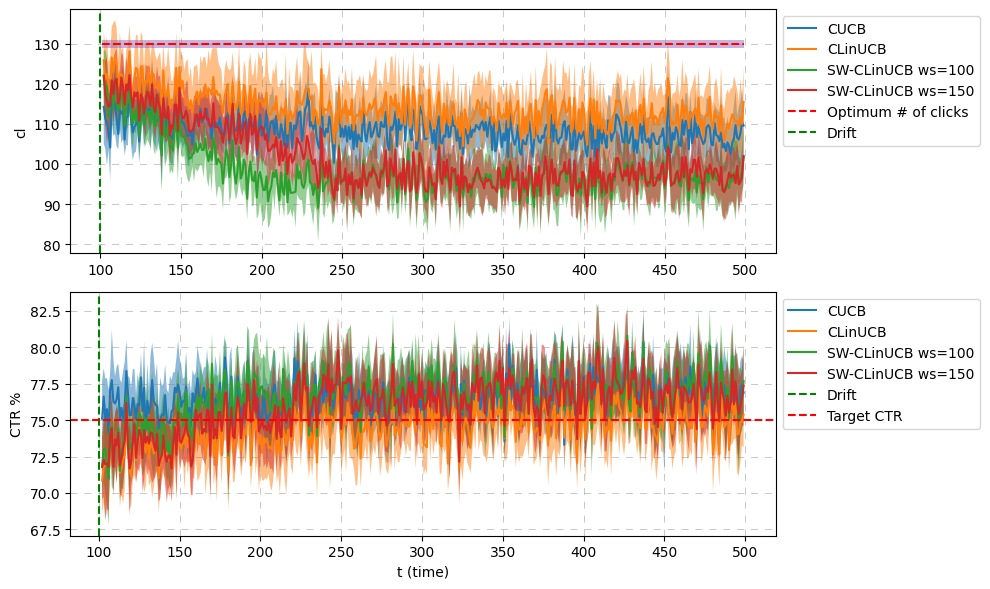

In [72]:
plot_click_ctr(models, iteration=101, iteration_drift=100)

## Stationary

### CTR = 86%

In [6]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_86_07_02_25/'
cucb_results, cucb_opt_results = group_data(cucb_exp_dir)

In [7]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_86_07_02_25/'
linucb_results, linucb_opt_res = group_data(linucb_exp_dir)

In [8]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}

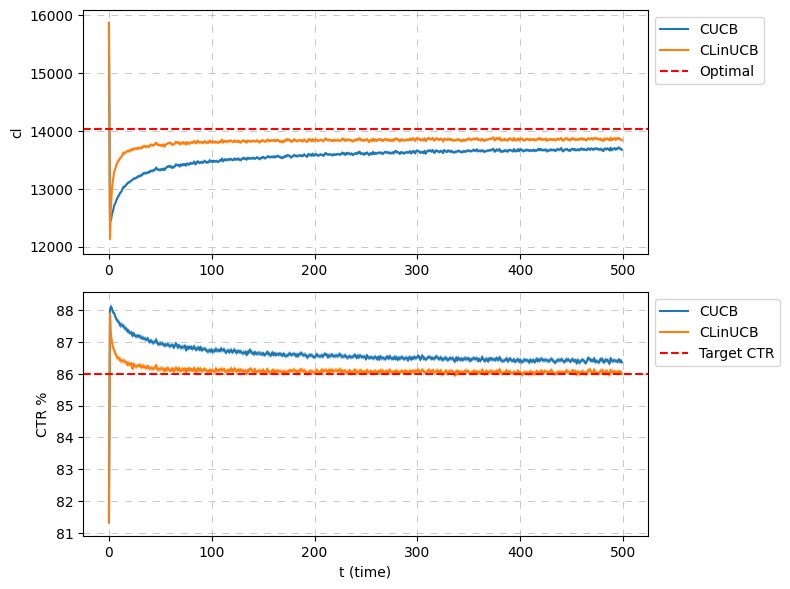

In [11]:
plot_click_ctr(models, iteration=-11,
               #save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_ctr_0_86_07_02_25.pdf'
               )

### CTR = 90%

In [6]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_9_29_01_25/'
cucb_results, cucb_opt_results = group_data(cucb_exp_dir)

In [7]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_9_29_01_25/'
linucb_results, linucb_opt_res = group_data(linucb_exp_dir)

In [8]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}

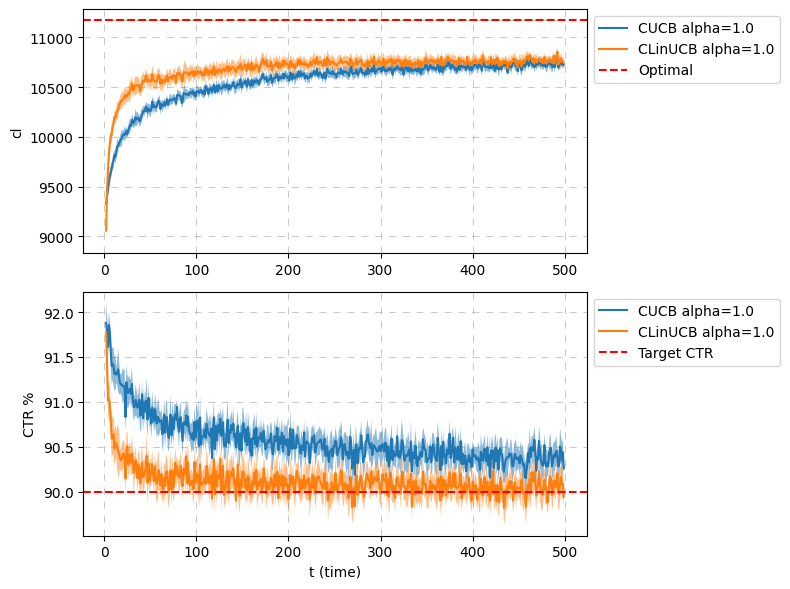

In [10]:
plot_click_ctr(models, iteration=1, alpha_inlcude_list=[1],
               #save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_ctr_0_9_29_01_25.pdf'
               )

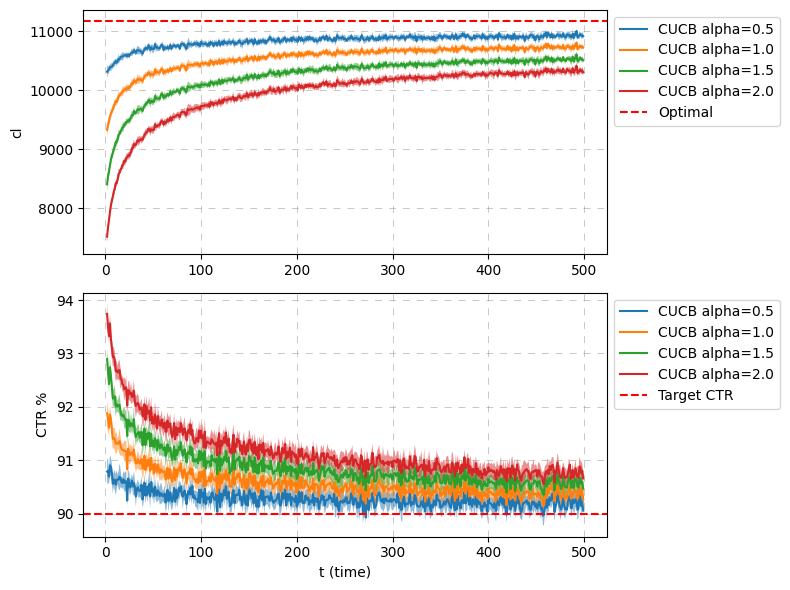

In [9]:
models = {
    'CUCB': cucb_results, 
    #'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}
plot_click_ctr(models, iteration=1,
               #save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_ctr_0_9_29_01_25.pdf'
               )

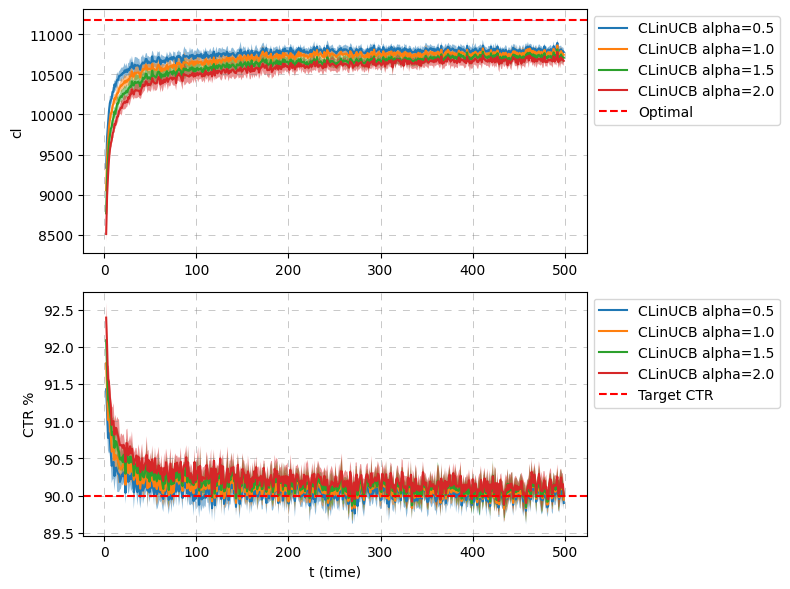

In [10]:
models = {
    #'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}
plot_click_ctr(models, iteration=1,
               #save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_ctr_0_9_29_01_25.pdf'
               )

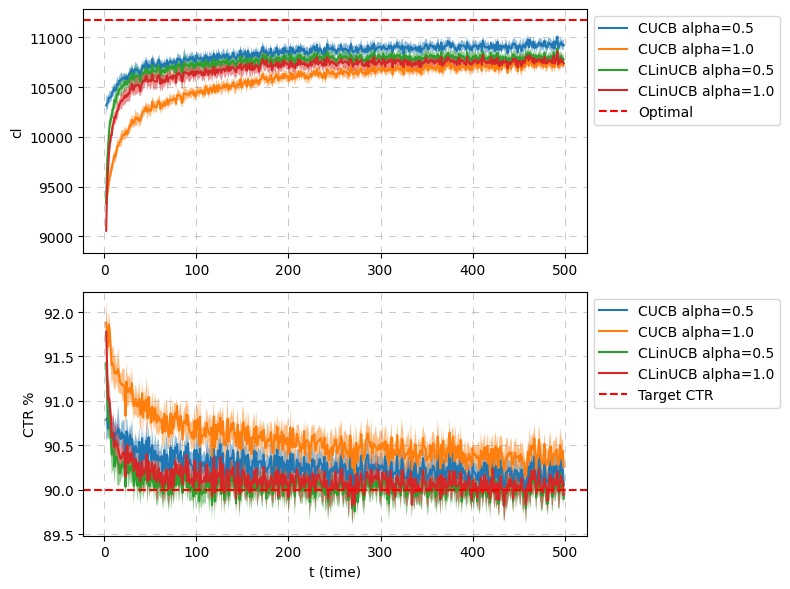

In [11]:
models = {
    'CUCB': cucb_results,
    'CLinUCB': linucb_results,
    'opt': linucb_opt_res
}
plot_click_ctr(models, iteration=1, alpha_inlcude_list=[0.5, 1])

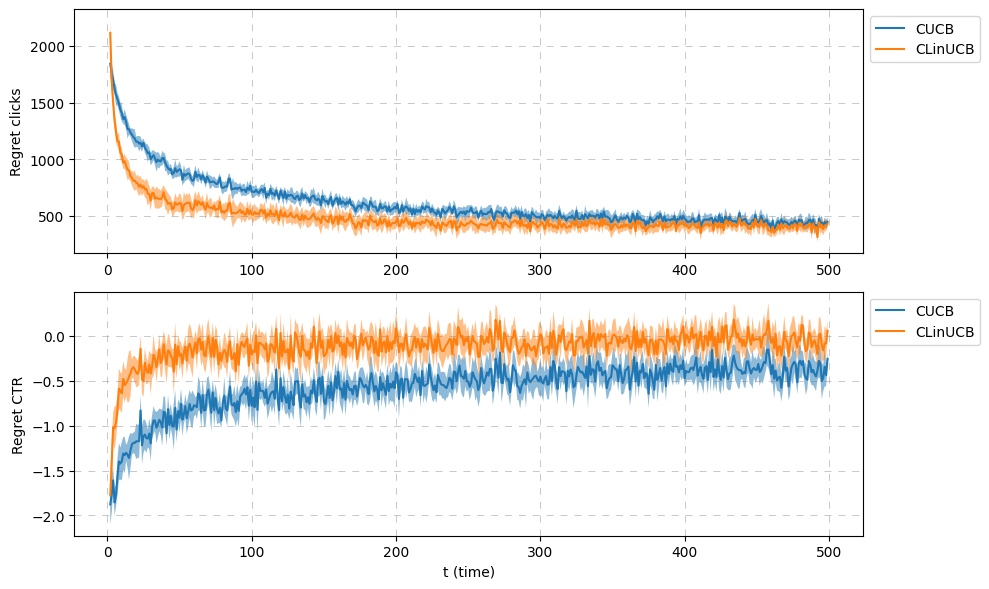

In [49]:
plot_regret_click_ctr(models, iteration=1)

In [17]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_9_05_02_25/'
cucb_results, cucb_opt_results = group_data(cucb_exp_dir)

In [18]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_9_05_02_25/'
linucb_results, linucb_opt_res = group_data(linucb_exp_dir)

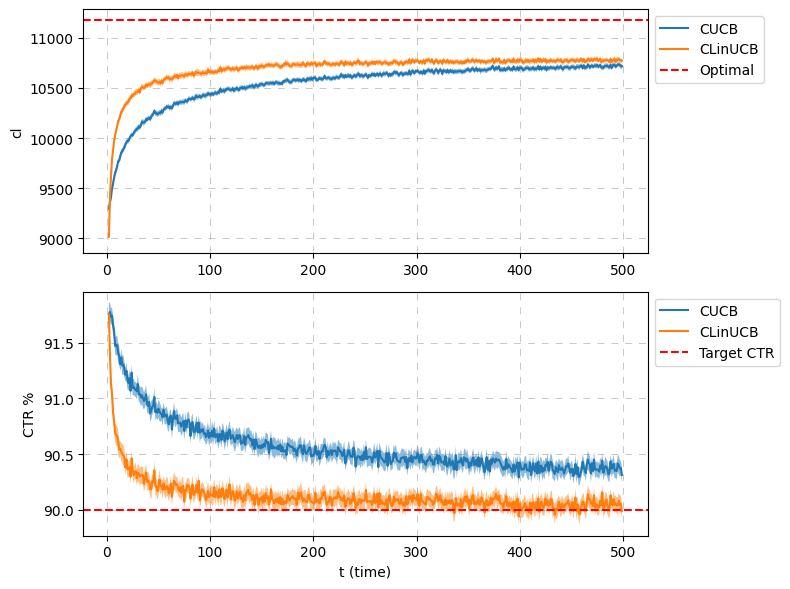

In [19]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}

plot_click_ctr(models, iteration=1,
               save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_ctr_0_9_29_01_25.pdf'
               )

### CTR = 97%

In [40]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_97_29_01_25/'
cucb_results, cucb_opt_results = group_data(cucb_exp_dir)

In [41]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_97_29_01_25/'
linucb_results, linucb_opt_res = group_data(linucb_exp_dir)

In [42]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': cucb_opt_results
}

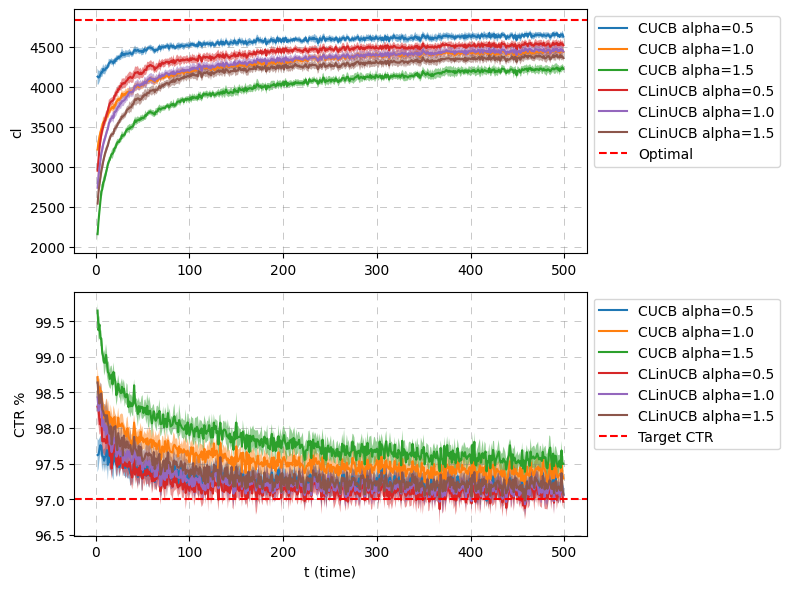

In [20]:
plot_click_ctr(models, iteration=1, alpha_inlcude_list=[0.5, 1, 1.5],
               #save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_ctr_0_97_29_01_25.pdf'
               )

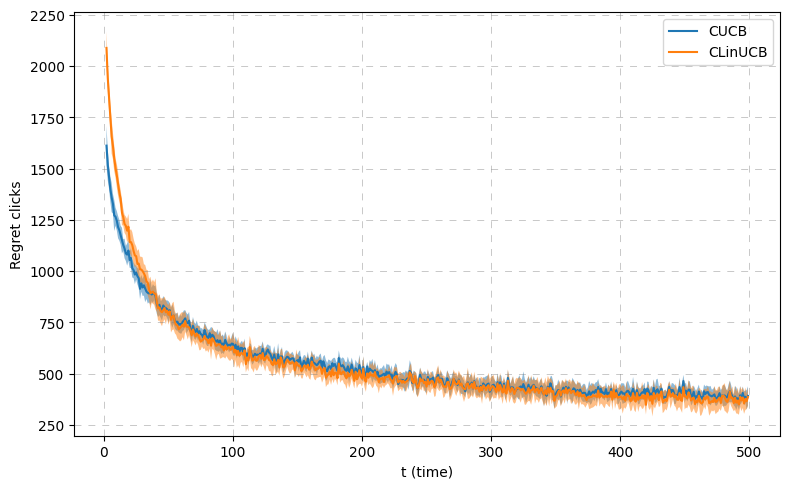

In [92]:
plot_regret_click_ctr(models, iteration=1)

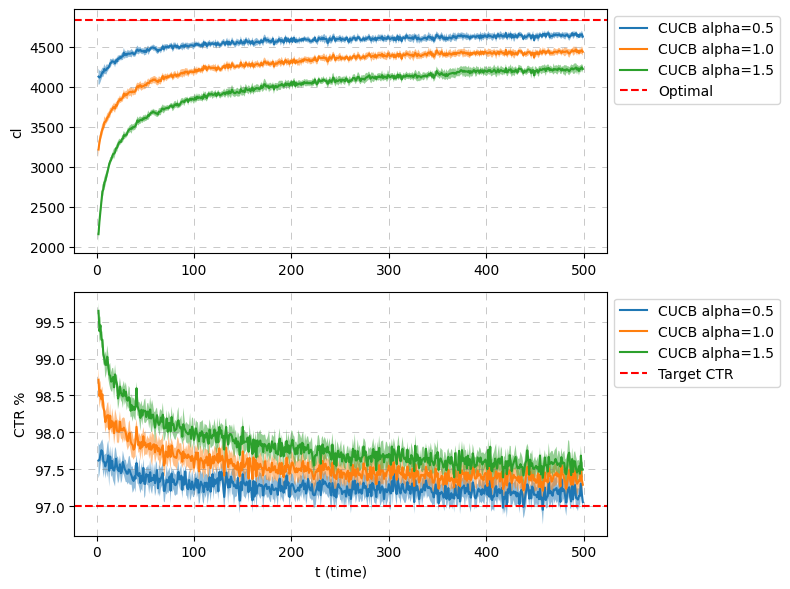

In [16]:
plot_click_ctr(
    gr_res_models={'CUCB': cucb_results,'opt': cucb_opt_results},
    iteration=1,
    alpha_inlcude_list=[0.5, 1, 1.5]
)

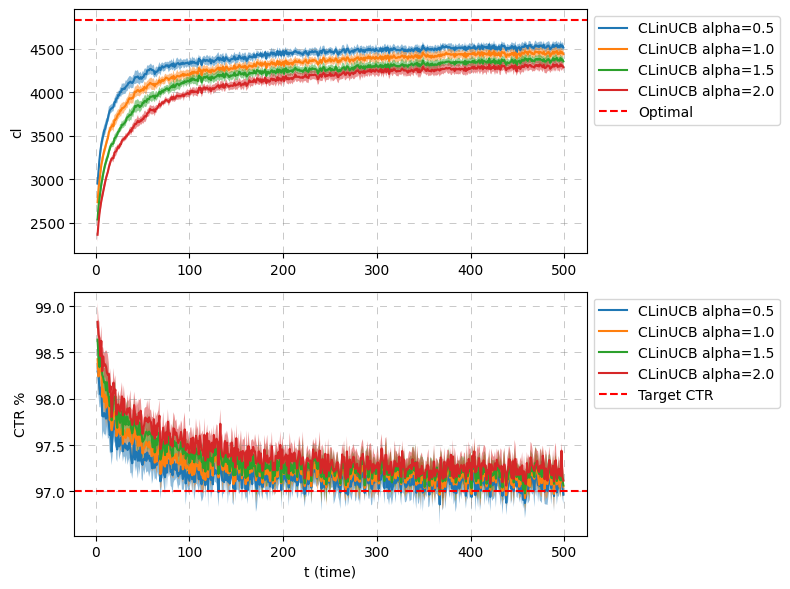

In [17]:
plot_click_ctr(
    gr_res_models={'CLinUCB': linucb_results,'opt': linucb_opt_res}, 
    iteration=1, 
    #alpha_inlcude_list=[0.5, 1, 1.5]
)

In [45]:
linucb_norescale_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_textemb_ctr_0_97_07_02_25/'
linucb_norescale_results, linucb_norescale_opt_res = group_data(linucb_norescale_exp_dir)

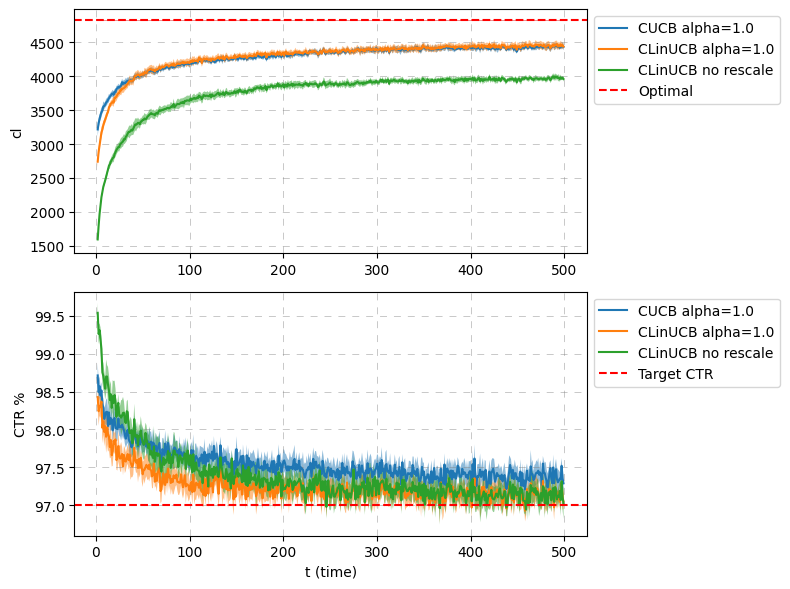

In [46]:
plot_click_ctr(
    gr_res_models={
        'CUCB': cucb_results,
        'CLinUCB': linucb_results,
        'opt': linucb_opt_res, 
        'CLinUCB no rescale': linucb_norescale_results
    }, 
    iteration=1,
    alpha_inlcude_list=[1]
)

In [27]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_97_05_02_25/'
cucb_results, cucb_opt_results = group_data(cucb_exp_dir)

In [28]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_97_05_02_25/'
linucb_results, linucb_opt_res = group_data(linucb_exp_dir)

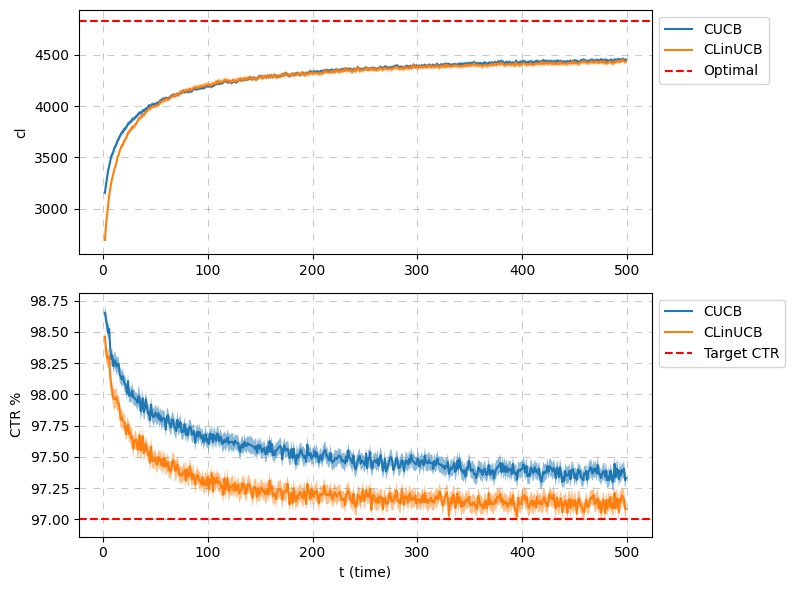

In [29]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': cucb_opt_results
}

plot_click_ctr(models, iteration=1,
               save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_ctr_0_97_05_02_25.pdf'
               )

### Dopo solo 1 iterazione di prova di tutti i publisher

In [42]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_97_06_02_25_only1iter/'
cucb_results, cucb_opt_results = group_data(cucb_exp_dir)

In [43]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_ctr_0_97_06_02_25_only1iter/'
linucb_results, linucb_opt_res = group_data(linucb_exp_dir)

In [44]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': cucb_opt_results
}

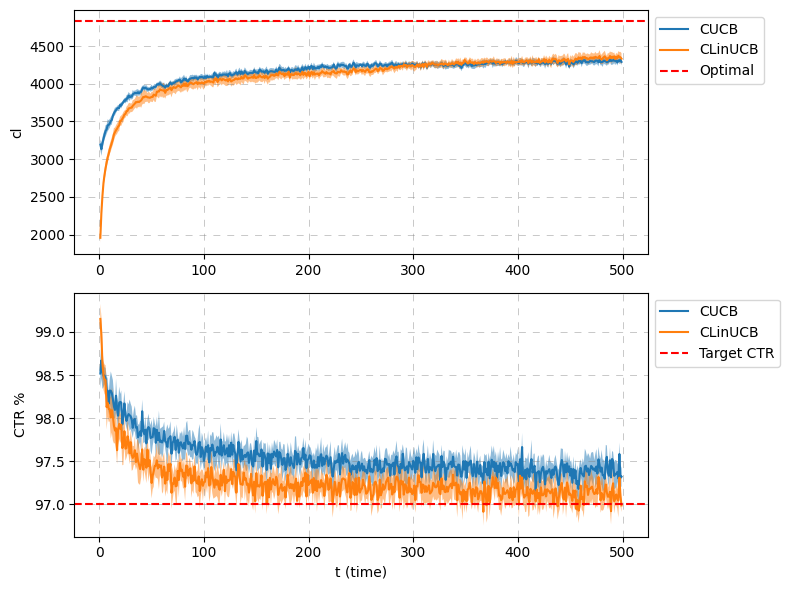

In [51]:
plot_click_ctr(models, iteration=0)

### CTR = 99%

In [28]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_99_29_01_25/'
cucb_results, cucb_opt_results = group_data(cucb_exp_dir)

In [22]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_99_29_01_25/'
linucb_results, linucb_opt_res = group_data(linucb_exp_dir)

In [83]:
swlinucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swlinucb_rescaledtextemb_ctr_0_99_03_02_25_nodrift/'
swlinucb_results = group_data_sw(swlinucb_exp_dir)

In [16]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    #'SW-CLinUCB': swlinucb_results,
    'opt': linucb_opt_res
}

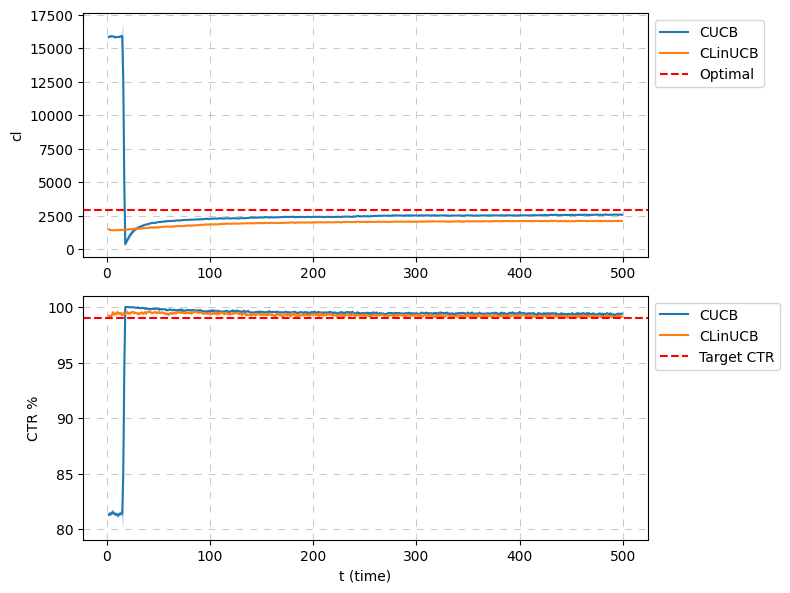

In [17]:
plot_click_ctr(models, iteration=1, save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_1iter_ctr_0_99_29_01_25.pdf')

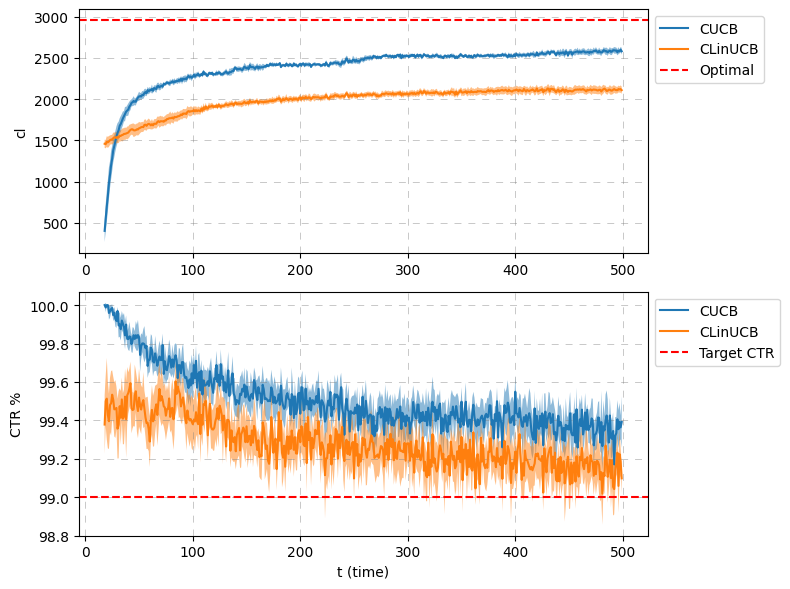

In [18]:
plot_click_ctr(models, iteration=17, save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_17iter_ctr_0_99_29_01_25.pdf')

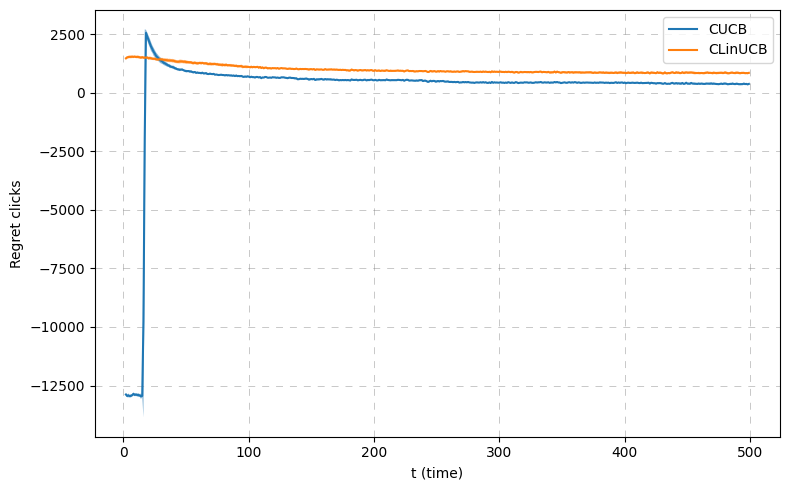

In [28]:
plot_regret_click_ctr(models, iteration=1)

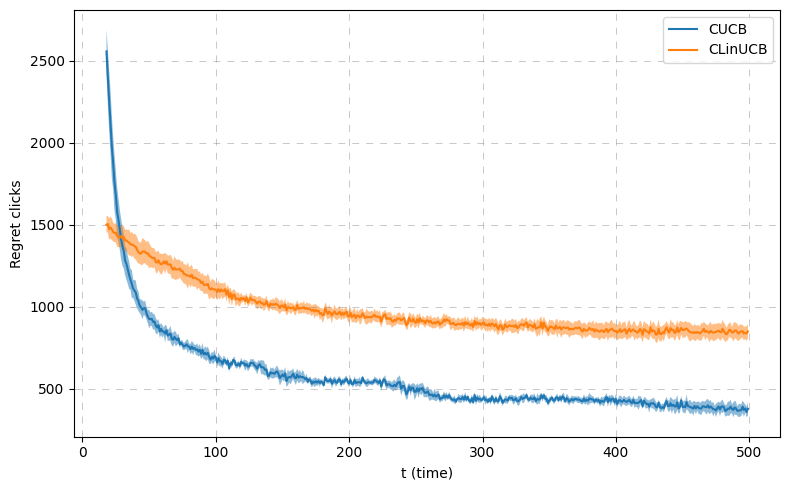

In [74]:
plot_regret_click_ctr(models, iteration=17)

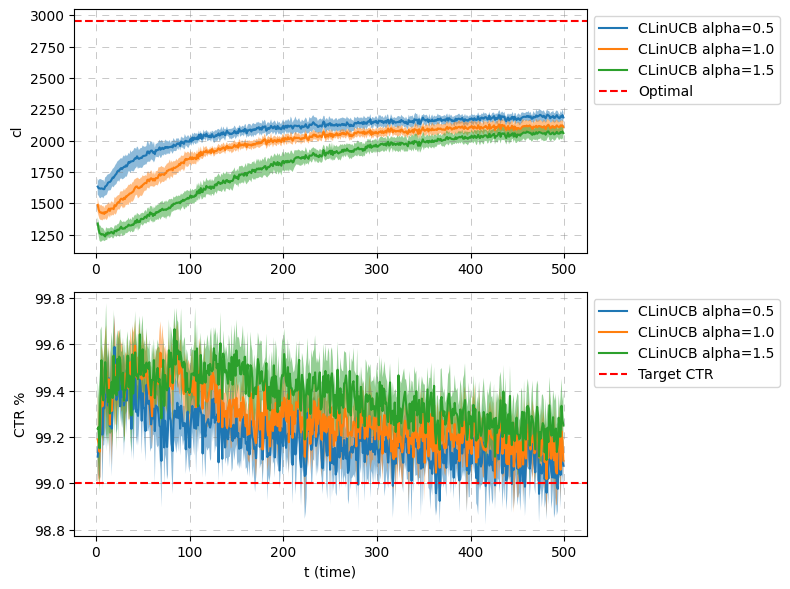

In [26]:
plot_click_ctr(
    gr_res_models={'CLinUCB': linucb_results,'opt': linucb_opt_res}, 
    iteration=1, 
    #alpha_inlcude_list=[0.5, 1, 1.5]
)

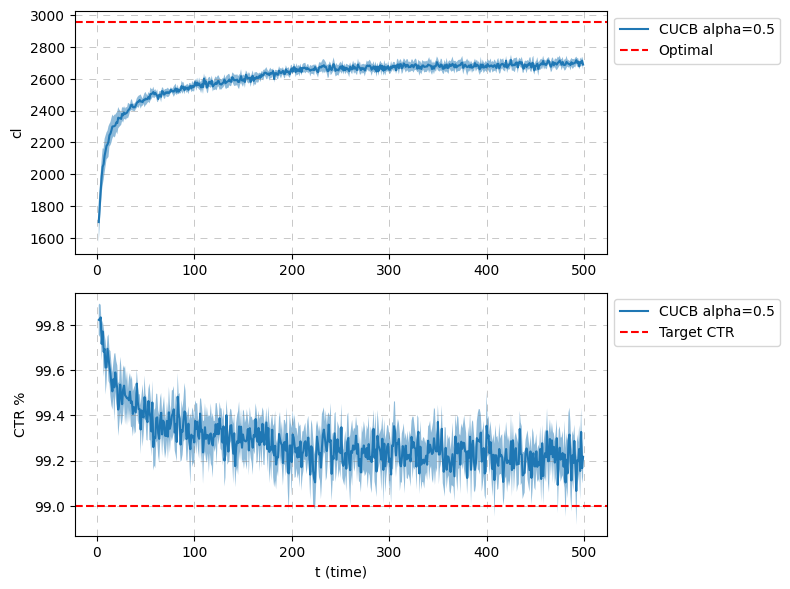

In [37]:
plot_click_ctr(
    gr_res_models={'CUCB': cucb_results, 'opt': cucb_opt_results}, 
    iteration=1, 
    alpha_inlcude_list=[0.5]
)

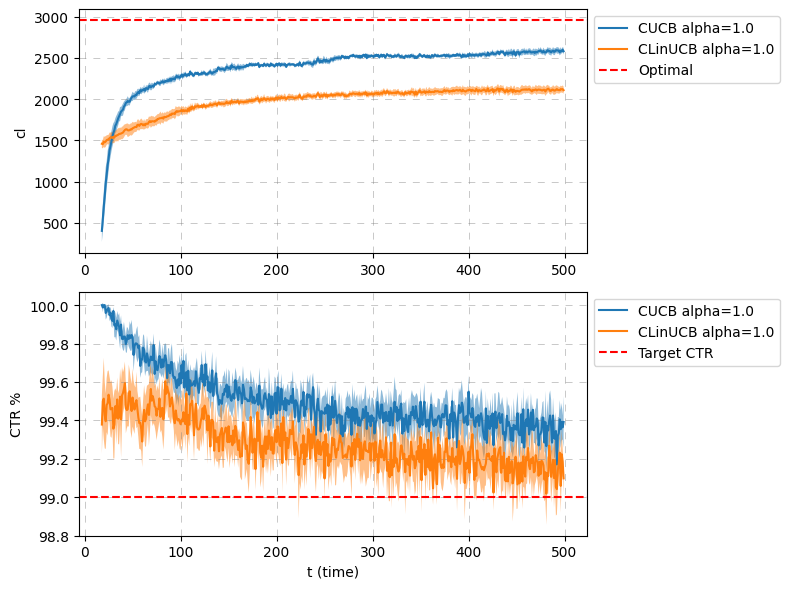

In [41]:
plot_click_ctr(
    gr_res_models={'CUCB': cucb_results,'CLinUCB': linucb_results,'opt': linucb_opt_res}, 
    iteration=17, 
    alpha_inlcude_list=[1]
)

In [22]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_99_05_02_25/'
cucb_results, cucb_opt_results = group_data(cucb_exp_dir)

In [23]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_99_05_02_25/'
linucb_results, linucb_opt_res = group_data(linucb_exp_dir)

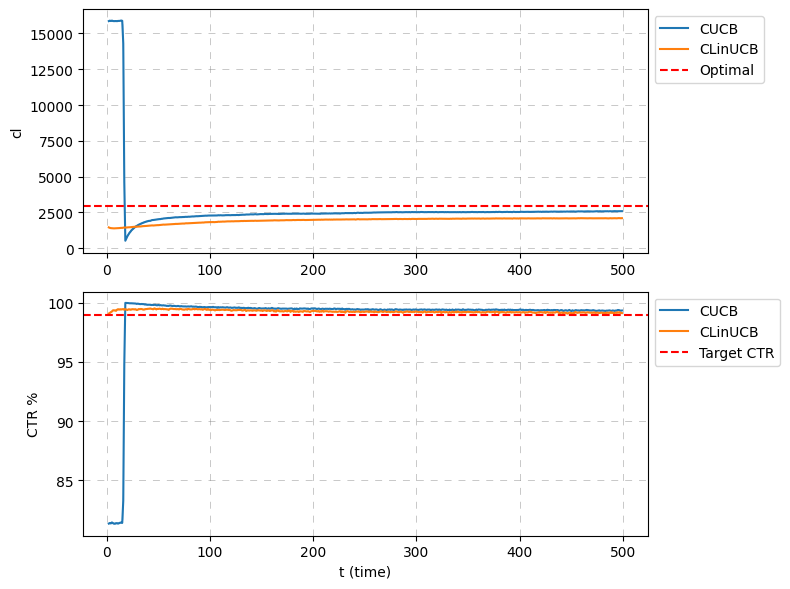

In [24]:
models = {
    'CUCB': cucb_results,
    'CLinUCB': linucb_results,
    'opt': linucb_opt_res
}

plot_click_ctr(models, iteration=1,
               save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_1iter_ctr_0_99_05_02_25.pdf'
               )

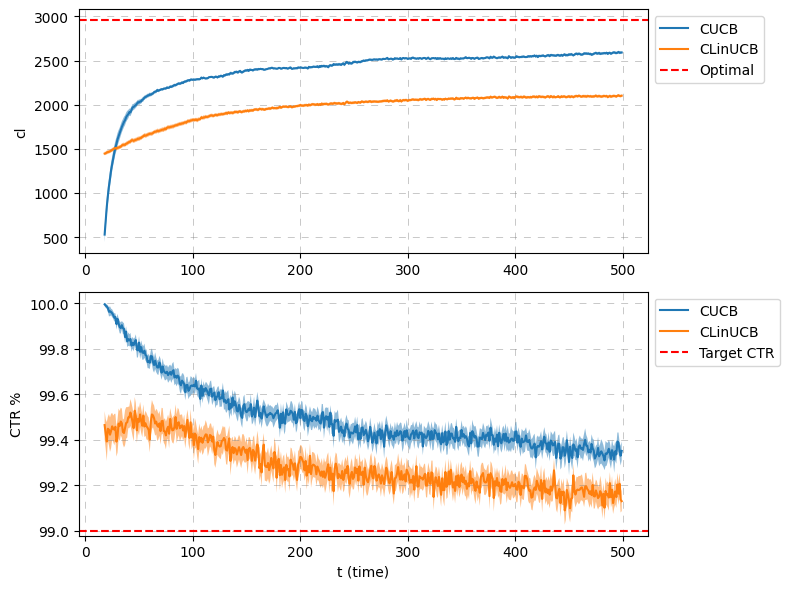

In [26]:
plot_click_ctr(models, iteration=17,
               save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_17iter_ctr_0_99_05_02_25.pdf'
               )

## SW (dopo il drift l'unica cosa che cambia nei dati è la bid del nostro agente che è ridotta del 20%)

### CTR = 90%

In [28]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_drift_ctr_0_9_29_01_25/'
cucb_results, cucb_opt_res_before, cucb_opt_res_after = group_data(cucb_exp_dir)

In [29]:
swcucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swcucb_ctr_0_9_29_01_25/'
swcucb_results, swcucb_opt_res_before_drift, swcucb_opt_res_after_drift = group_data_sw(swcucb_exp_dir, iteration_drift=100)

In [30]:
swlinucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swlinucb_rescaledtextemb_ctr_0_9_29_01_25/'
swlinucb_results, swlinucb_opt_res_before_drift, swlinucb_opt_res_after_drift = group_data_sw(swlinucb_exp_dir, iteration_drift=100)

In [31]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_drift_rescaledtextemb_ctr_0_9_29_01_25/'
linucb_results, linucb_opt_res_before, linucb_opt_res_after = group_data(linucb_exp_dir)

In [55]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results,
    'SW-CLinUCB': swlinucb_results,
    'SW-CUCB': swcucb_results,
    'Optimal after drift': swlinucb_opt_res_after_drift,
    'Optimal before drift': swlinucb_opt_res_before_drift
}

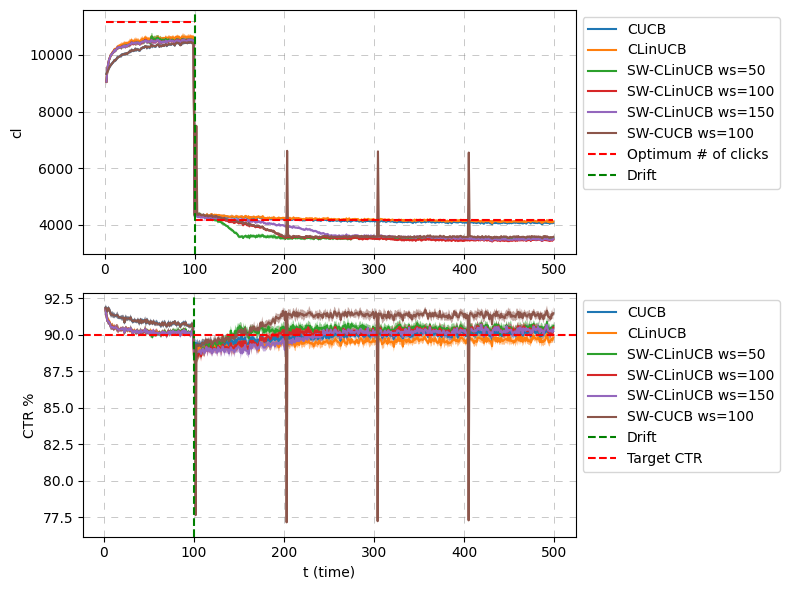

In [56]:
plot_click_ctr(models, iteration=1, iteration_drift=100)

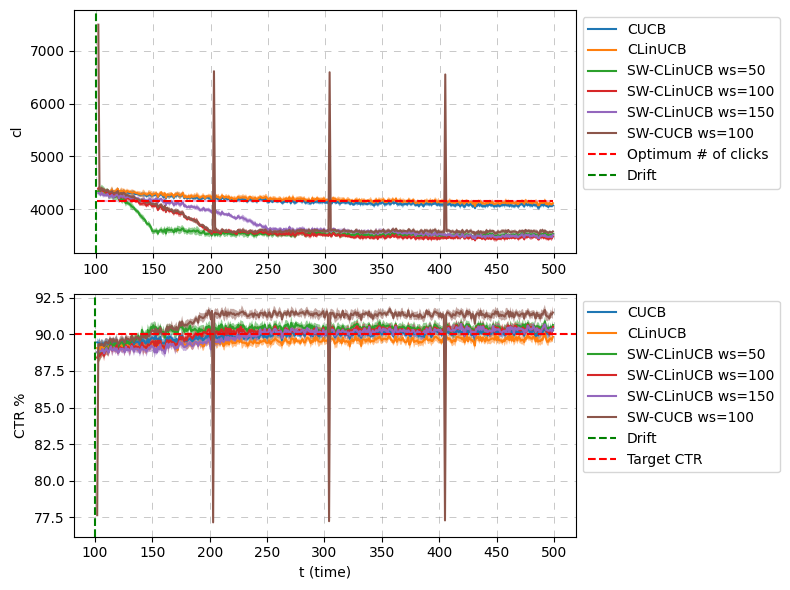

In [57]:
plot_click_ctr(models, iteration=101, iteration_drift=100)

### I migliori pre-drift sono i migliori anche post?

In [32]:
def read_all_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    pattern_sw = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)_ws_(\d+)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        match_sw = re.search(pattern_sw, file)
        if match_sw:
            num_run = int(match_sw.group(1))
            soglia_ctr = float(match_sw.group(2))
            alpha = float(match_sw.group(3))
            ws = int(match_sw.group(4))

            curr_results = pd.read_csv(dir_path + file)

            curr_results['Run'] = num_run
            curr_results['soglia_ctr'] = soglia_ctr
            curr_results['alpha'] = alpha
            curr_results['ws'] = ws

            results = pd.concat([results, curr_results])
        elif match:
            num_run = int(match.group(1))
            soglia_ctr = float(match.group(2))
            alpha = float(match.group(3))

            curr_results = pd.read_csv(dir_path + file)
            
            curr_results['alpha'] = alpha
            curr_results['Run'] = num_run
            curr_results['soglia_ctr'] = soglia_ctr
            
            results = pd.concat([results, curr_results])
            
    return results

In [33]:
cucb_all_res = read_all_data(cucb_exp_dir)

In [39]:
mean_n_pub_superarm_pre = cucb_all_res[cucb_all_res['Iteration']==99].groupby('Run').agg({'publisher':'nunique'}).mean().values[0]
mean_n_pub_superarm_pre

132.4

In [34]:
pre_drift_cucb = cucb_all_res[cucb_all_res['Iteration']==99].groupby(['publisher']).agg({'clicks': 'mean', 'impressions': 'mean', 'Run': 'nunique'}).reset_index()

In [35]:
post_drift_cucb = cucb_all_res[cucb_all_res['Iteration']==499].groupby(['publisher']).agg({'clicks': 'mean', 'impressions': 'mean', 'Run': 'nunique'}).reset_index()

In [41]:
mean_n_pub_superarm_post = cucb_all_res[cucb_all_res['Iteration']==499].groupby('Run').agg({'publisher':'nunique'}).mean().values[0]
mean_n_pub_superarm_post

123.5

### Most chosen publishers in the last iteration pre and post

In [45]:
pre_drift_cucb_10runs = pre_drift_cucb[pre_drift_cucb['Run'] == 10]
pre_drift_cucb_pub = set(pre_drift_cucb_10runs['publisher'].tolist())
print(f'Number of the most chosen (10/10) publishers before drift: {len(pre_drift_cucb_pub)} / {mean_n_pub_superarm_pre}')
print(f'CTR = {pre_drift_cucb_10runs['clicks'].sum() /pre_drift_cucb_10runs['impressions'].sum()}')

post_drift_cucb_10runs = post_drift_cucb[post_drift_cucb['Run'] == 10]
post_drift_cucb_pub = set(post_drift_cucb_10runs['publisher'].tolist())
print(f'Number of the most chosen (10/10) publishers after drift: {len(post_drift_cucb_pub)} / {mean_n_pub_superarm_post}')
print(f'CTR = {post_drift_cucb_10runs['clicks'].sum() / post_drift_cucb_10runs['impressions'].sum()}')

common_pub = pre_drift_cucb_pub.intersection(post_drift_cucb_pub)
print(f'Common publishers: {len(common_pub)}')

Number of the most chosen (10/10) publishers before drift: 107 "/" 132.4
CTR = 0.924158787037708
Number of the most chosen (10/10) publishers after drift: 107 / 123.5
CTR = 0.9145624700451529
Common publishers: 107


From the least chosen how many are common pre and before?

In [47]:
pre_drift_cucb_10runs = pre_drift_cucb[(pre_drift_cucb['Run'] > 4)&(pre_drift_cucb['Run'] < 10)]
pre_drift_cucb_pub = set(pre_drift_cucb_10runs['publisher'].tolist())

post_drift_cucb_10runs = post_drift_cucb[(post_drift_cucb['Run'] > 4)&(post_drift_cucb['Run'] < 10)]
post_drift_cucb_pub = set(post_drift_cucb_10runs['publisher'].tolist())

common_pub = pre_drift_cucb_pub.intersection(post_drift_cucb_pub)
print(f'Common publishers: {len(common_pub)}')

Common publishers: 21


In [79]:
pre_post_drift_cucb = pd.merge(
    pre_drift_cucb[pre_drift_cucb['Run'] == 10],
    post_drift_cucb[post_drift_cucb['Run'] == 10],
    on='publisher',
    suffixes=('_pre', '_post')
)
pre_post_drift_cucb['clicks_pre_80%'] = pre_post_drift_cucb['clicks_pre'] * 0.8
pre_post_drift_cucb

,publisher,clicks_pre,Run_pre,clicks_post,Run_post,clicks_pre_80%
0,gazzettadimantova.it,117.1,10,60.0,10,93.68
1,motociclismo.it,116.5,10,16.3,10,93.20
2,motorsport.nextgen-auto.com,116.3,10,30.7,10,93.04
3,forocoches.com,115.9,10,4.8,10,92.72
4,coches.net,115.8,10,41.7,10,92.64
...,...,...,...,...,...,...
102,universfreebox.com,45.7,10,43.6,10,36.56
103,huffingtonpost.es,43.3,10,3.9,10,34.64
104,fragrantica.ru,28.8,10,3.7,10,23.04
105,es.pons.com,23.9,10,0.0,10,19.12


### In media quale modello viola di più il vincolo dopo il drift?

In [90]:
iteration_drift = 100

In [112]:
def filter_results(results, iteration_drift):
    return results[(results['Iteration']>iteration_drift)]

def get_mean_ctr_violation(filtered_results, target_ctr):
    res_mean_ctr = filtered_results['ctr'].mean()
    res_mean_ctr_violation = (np.abs(target_ctr-res_mean_ctr) / target_ctr) * 100
    return res_mean_ctr_violation

def models_mean_violation(models: dict, target_ctr, iteration_drift):
    res = {}
    for model, gr_res in models.items():
        if model == 'opt' or model == 'Optimal after drift' or model == 'Optimal before drift':
            continue
        filtered_results = filter_results(gr_res, iteration_drift)
        res[model] = get_mean_ctr_violation(filtered_results, target_ctr)
    res_df = pd.DataFrame(res.items(), columns=['Model', 'Mean CTR Violation']).sort_values(by='Mean CTR Violation')
    return res_df

In [118]:
models = {
    'CUCB': cucb_results,
    'CLinUCB': linucb_results,
    'SW-CLinUCB (ws=50)': swlinucb_results[swlinucb_results['ws']==50],
    'SW-CLinUCB (ws=100)': swlinucb_results[swlinucb_results['ws']==100],
    'SW-CLinUCB (ws=150)': swlinucb_results[swlinucb_results['ws']==150],
    'SW-CUCB': swcucb_results
}

In [119]:
models_mean_violation(models, 0.9, iteration_drift)

,Model,Mean CTR Violation
3,SW-CLinUCB (ws=100),0.050328
0,CUCB,0.088211
4,SW-CLinUCB (ws=150),0.111163
2,SW-CLinUCB (ws=50),0.348000
1,CLinUCB,0.550801
5,SW-CUCB,1.027885


## SW. Bid dopo 100 iterazioni è la metà

### CTR = 90%

In [75]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_drift_ctr_0_9_29_01_25_halfbid/'
cucb_results, cucb_opt_results = group_data(cucb_exp_dir)

KeyError: 'Run'

In [ ]:
swcucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swcucb_ctr_0_9_29_01_25/'
swcucb_results = group_data(swcucb_exp_dir)

In [123]:
swlinucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swlinucb_rescaledtextemb_ctr_0_9_29_01_25_halfbid/'
swlinucb_results = group_data_sw(swlinucb_exp_dir)
swlinucb_opt_res_after_drift, swlinucb_opt_res_before_drift = group_opt_data_sw(swlinucb_exp_dir)

In [127]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_drift_rescaledtextemb_ctr_0_9_29_01_25_halfbid/'
linucb_results = group_data(linucb_exp_dir)

In [136]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results,
    'SW-CLinUCB': swlinucb_results,
    #'SW-CUCB': swcucb_results,
    'Optimal after drift': swlinucb_opt_res_after_drift,
    'Optimal before drift': swlinucb_opt_res_before_drift
}

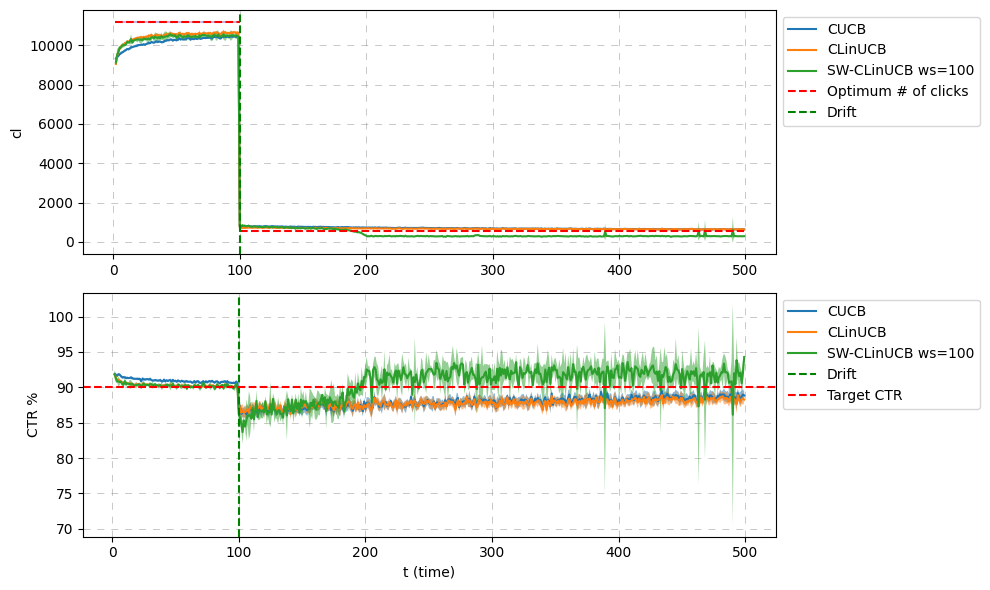

In [137]:
plot_click_ctr(models, iteration=1, iteration_drift=100)

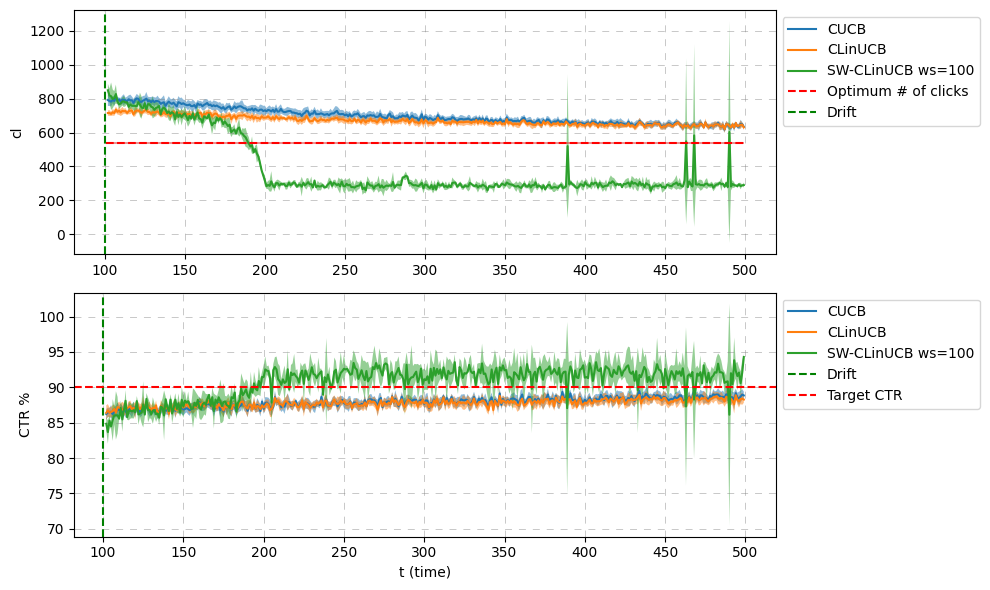

In [138]:
plot_click_ctr(models, iteration=101, iteration_drift=100)

In [139]:
models_mean_violation(models, 0.9, iteration_drift)

,Model,Mean CTR Violation
2,SW-CLinUCB,0.769717
0,CUCB,2.372821
1,CLinUCB,2.499142


## SW - Dopo il drift cambiano i partecipanti alle aste

### CTR = 90%

In [13]:
swlinucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swlinucb_rescaledtextemb_ctr_0_9_30_01_25_newagents/'
swlinucb_results, swlinucb_opt_res_before_drift, swlinucb_opt_res_after_drift = group_data_sw(swlinucb_exp_dir, iteration_drift=100)

In [14]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_drift_rescaledtextemb_ctr_0_9_30_01_25_newagents/'  
linucb_results, linucb_opt_res_before_drift, linucb_opt_res_after_drift = group_data(linucb_exp_dir, iteration_drift=100)

In [15]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_drift_ctr_0_9_30_01_25_newagents/'
cucb_results, cucb_opt_results_before_drift, cucb_opt_results_after_drift = group_data(cucb_exp_dir, iteration_drift=100)

In [16]:
swcucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swcucb_ctr_0_9_30_01_25_newagents/'
swcucb_results, swcucb_opt_res_before_drift, swcucb_opt_res_after_drift = group_data_sw(swcucb_exp_dir, iteration_drift=100)

In [27]:
swcucb_results[swcucb_results['Iteration'] == 250]

,soglia_ctr,ws,alpha,Iteration,Run,clicks,impressions,publisher,ctr,clicks_optimal_before,...,impressions_ci,ctr_std,ctr_ci,publisher_std,publisher_ci,regret_clicks_before_std,regret_clicks_before_ci,regret_clicks_after_std,regret_clicks_after_ci,regret_clicks_ci
250,0.9,50,1.0,250,4.5,14629.3,16086.0,176.1,0.909445,11175.596,...,80.714567,0.001849,0.001146,0.875595,0.542699,117.755669,72.98572,116.857003,72.428721,72.428721


In [17]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results,
    'SW-CLinUCB': swlinucb_results,
    'SW-CUCB': swcucb_results,
    'Optimal after drift': swlinucb_opt_res_after_drift,
    'Optimal before drift': swlinucb_opt_res_before_drift
}

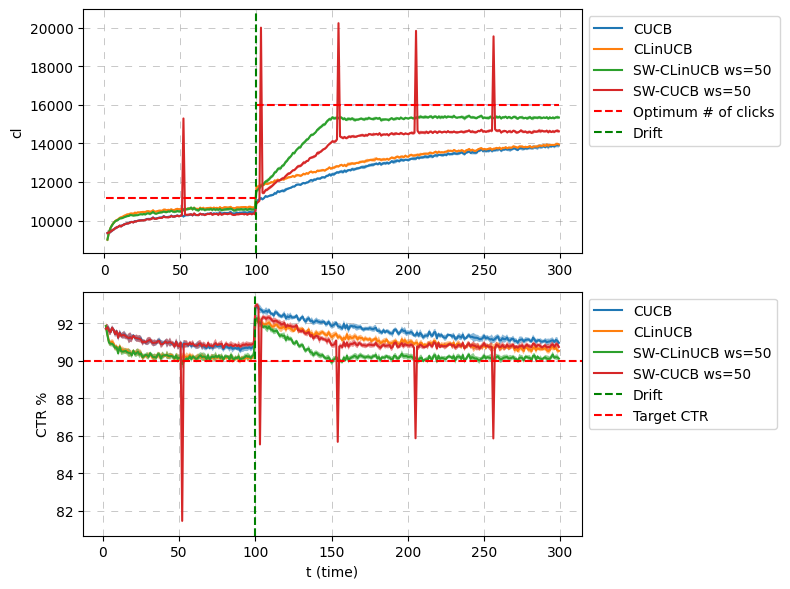

In [20]:
plot_click_ctr(models, iteration=1, iteration_drift=100,
               save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_swlinucb_swcucb_ctr_0_9_07_02_25_drift_newagents.pdf'               
               )

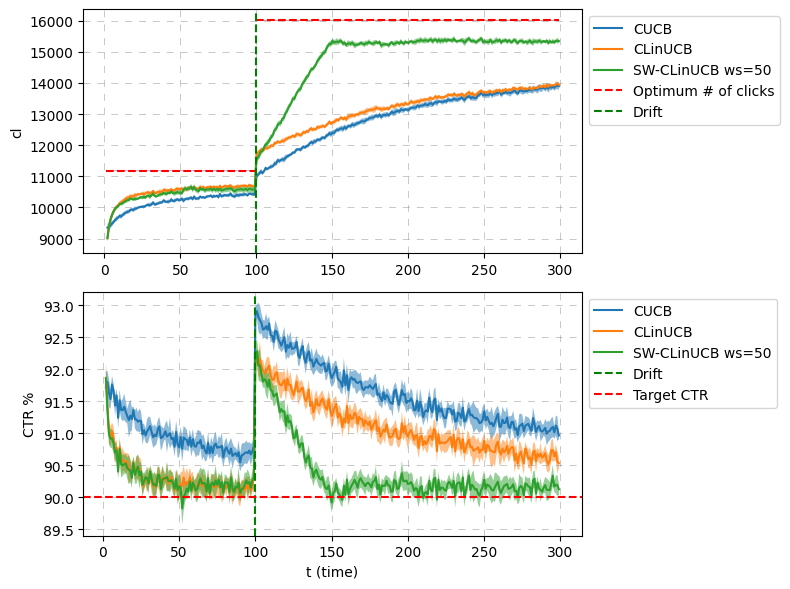

In [22]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results,
    'SW-CLinUCB': swlinucb_results,
    #'SW-CUCB': swcucb_results,
    'Optimal after drift': swlinucb_opt_res_after_drift,
    'Optimal before drift': swlinucb_opt_res_before_drift
}
plot_click_ctr(models, iteration=1, iteration_drift=100,
               save_path='../results/FP_Truthful_Oracle_sigmoids_cucb_linucb_swlinucb_ctr_0_9_07_02_25_drift_newagents.pdf'               
               )

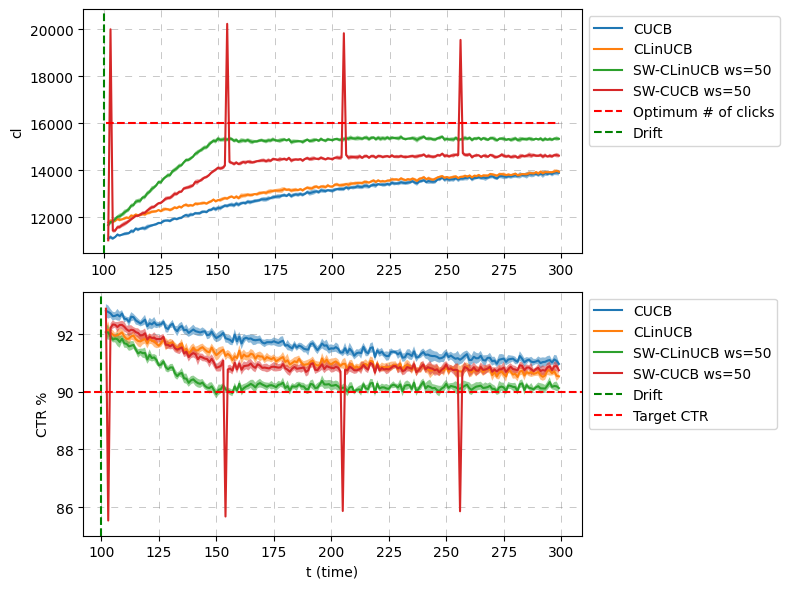

In [19]:
plot_click_ctr(models, iteration=101, iteration_drift=100)

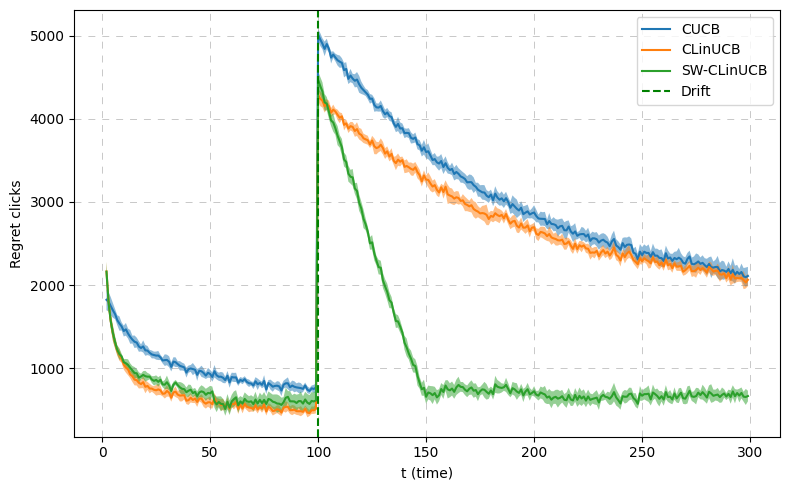

In [143]:
plot_regret_click_ctr(models, iteration=1, iteration_drift=100)

### CTR = 90%

In [30]:
swlinucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swlinucb_rescaledtextemb_ctr_0_9_03_02_25_prova/'
swlinucb_results, swlinucb_opt_res_before_drift, swlinucb_opt_res_after_drift = group_data_sw(swlinucb_exp_dir, iteration_drift=100)

In [31]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_drift_rescaledtextemb_ctr_0_9_31_01_25_prova/'
linucb_results, linucb_opt_res_before_drift, linucb_opt_res_after_drift = group_data(linucb_exp_dir, iteration_drift=100)

In [32]:
models = {
    'SW-CLinUCB': swlinucb_results,
    'CLinUCB': linucb_results,
    'Optimal after drift': swlinucb_opt_res_after_drift,
    'Optimal before drift': swlinucb_opt_res_before_drift
}

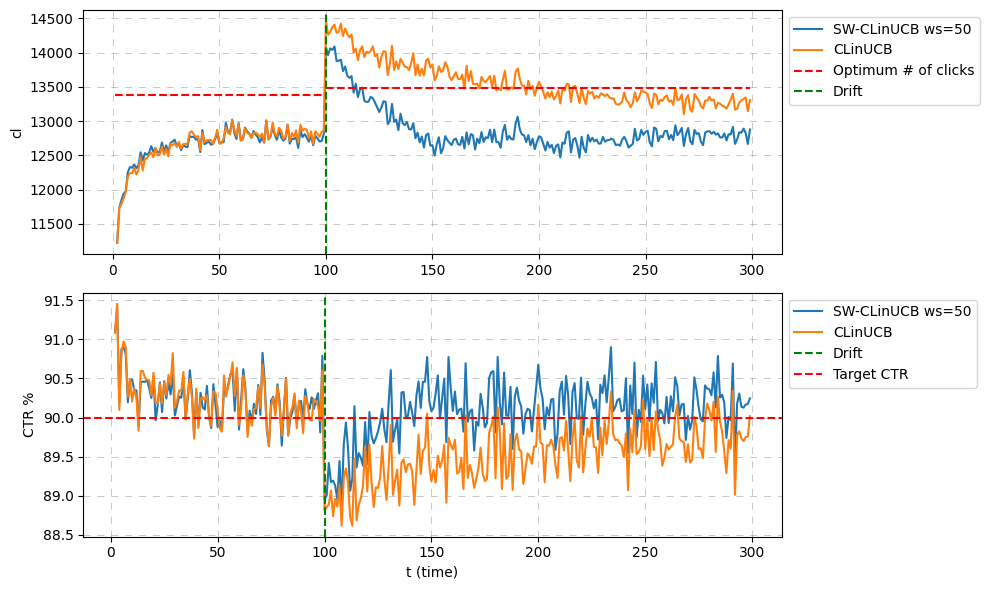

In [33]:
plot_click_ctr(models, iteration=1, iteration_drift=100)

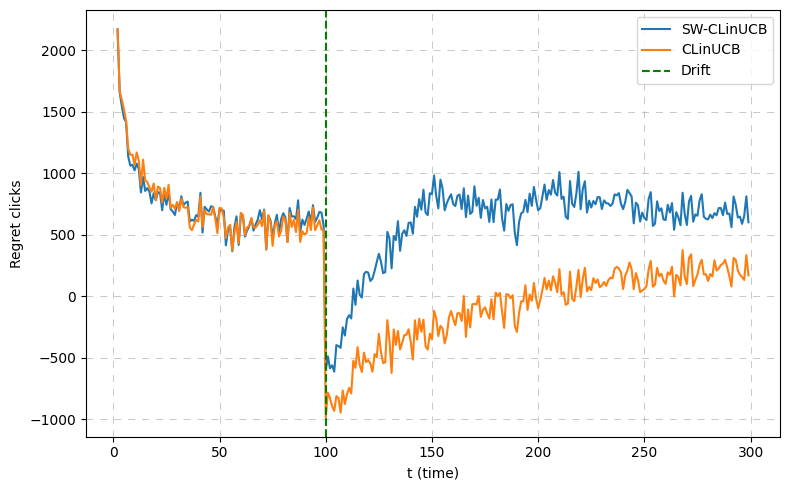

In [34]:
plot_regret_click_ctr(models, iteration=1, iteration_drift=100)

### SW 97%

In [18]:
swlinucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swlinucb_rescaledtextemb_ctr_0_97_03_02_25_prova/'
swlinucb_results, swlinucb_opt_res_before_drift, swlinucb_opt_res_after_drift = group_data_sw(swlinucb_exp_dir, iteration_drift=100)

In [19]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_97_03_02_25_prova/'
linucb_results, linucb_opt_res_before_drift, linucb_opt_res_after_drift = group_data(linucb_exp_dir, iteration_drift=100)

In [20]:
models = {
    'SW-CLinUCB': swlinucb_results,
    'CLinUCB': linucb_results,
    'Optimal after drift': swlinucb_opt_res_after_drift,
    'Optimal before drift': swlinucb_opt_res_before_drift
}

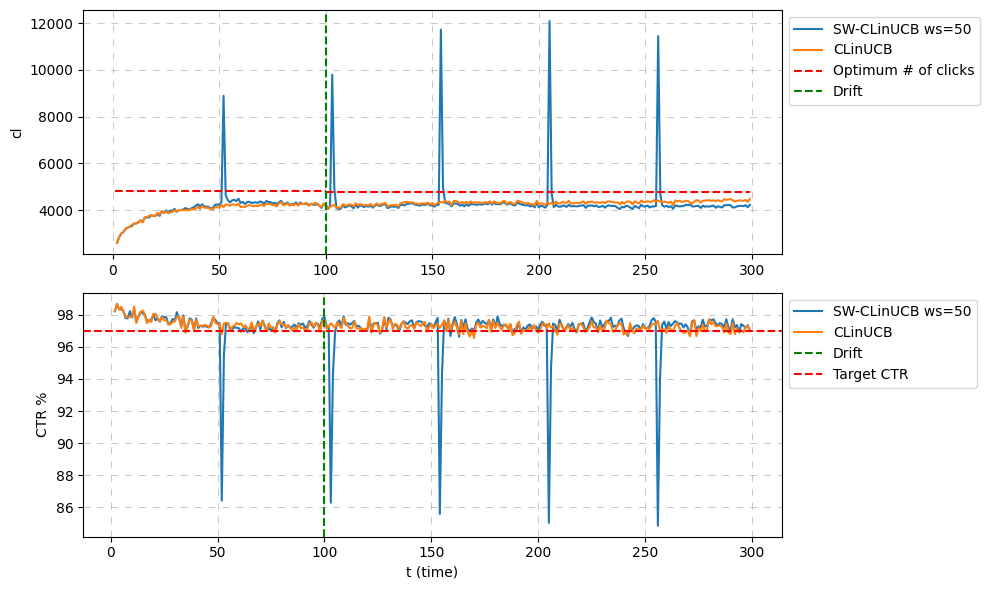

In [21]:
plot_click_ctr(models, iteration=1, iteration_drift=100)

### CTR = 99%

In [62]:
swlinucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swlinucb_rescaledtextemb_ctr_0_99_03_02_25_prova/'
swlinucb_results, swlinucb_opt_res_before_drift, swlinucb_opt_res_after_drift = group_data_sw(swlinucb_exp_dir, iteration_drift=100)

In [30]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_99_03_02_25_prova/'
linucb_results, linucb_opt_res_before_drift, linucb_opt_res_after_drift = group_data(linucb_exp_dir, iteration_drift=100)

In [31]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_drift_ctr_0_99_03_02_25_prova/'
cucb_results, cucb_opt_results_before_drift, cucb_opt_results_after_drift = group_data(cucb_exp_dir, iteration_drift=100)

In [35]:
swcucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_swcucb_ctr_0_99_03_02_25_prova/'
swcucb_results, swcucb_opt_res_before_drift, swcucb_opt_res_after_drift = group_data_sw(swcucb_exp_dir, iteration_drift=100)

In [39]:
models = {
    'SW-CLinUCB': swlinucb_results,
    #'SW-CUCB': swcucb_results,
    'CLinUCB': linucb_results,
    'CUCB': cucb_results,
    'Optimal after drift': swlinucb_opt_res_after_drift,
    'Optimal before drift': swlinucb_opt_res_before_drift
}

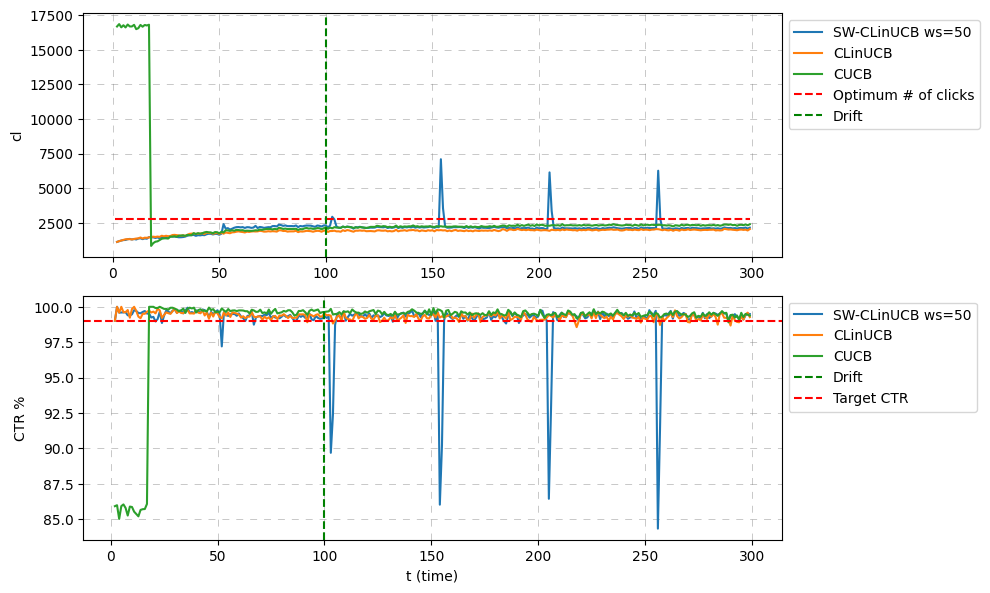

In [40]:
plot_click_ctr(models, iteration=1, iteration_drift=100)

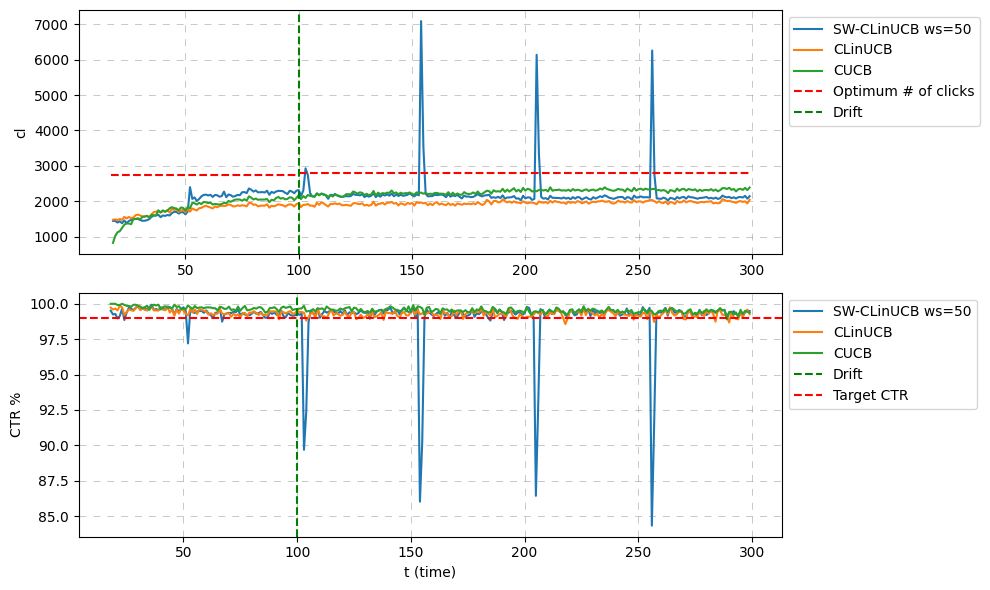

In [41]:
plot_click_ctr(models, iteration=17, iteration_drift=100)

### Analysis of SW results

In [42]:
def read_all_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    pattern_sw = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)_ws_(\d+)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        match_sw = re.search(pattern_sw, file)
        if match_sw:
            num_run = int(match_sw.group(1))
            soglia_ctr = float(match_sw.group(2))
            alpha = float(match_sw.group(3))
            ws = int(match_sw.group(4))

            curr_results = pd.read_csv(dir_path + file)

            curr_results['Run'] = num_run
            curr_results['soglia_ctr'] = soglia_ctr
            curr_results['alpha'] = alpha
            curr_results['ws'] = ws

            results = pd.concat([results, curr_results])
        elif match:
            num_run = int(match.group(1))
            soglia_ctr = float(match.group(2))
            alpha = float(match.group(3))

            curr_results = pd.read_csv(dir_path + file)
            
            curr_results['alpha'] = alpha
            curr_results['Run'] = num_run
            curr_results['soglia_ctr'] = soglia_ctr
            
            results = pd.concat([results, curr_results])
            
    return results

In [63]:
swlinucb_results

,soglia_ctr,ws,alpha,Iteration,Run,clicks,impressions,publisher,ctr,clicks_optimal_before,...,impressions_ci,ctr_std,ctr_ci,publisher_std,publisher_ci,regret_clicks_before_std,regret_clicks_before_ci,regret_clicks_after_std,regret_clicks_after_ci,regret_clicks_ci
0,0.99,50,1.0,0,0.0,16673.0,19427.0,287.0,0.858239,2737.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.99,50,1.0,1,0.0,16705.0,19592.0,287.0,0.852644,2737.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.99,50,1.0,2,0.0,1112.0,1123.0,11.0,0.990205,2737.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.99,50,1.0,3,0.0,1166.0,1166.0,10.0,1.000000,2737.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.99,50,1.0,4,0.0,1211.0,1216.0,11.0,0.995888,2737.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.99,50,1.0,295,0.0,2119.0,2131.0,19.0,0.994369,2737.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
296,0.99,50,1.0,296,0.0,2105.0,2124.0,19.0,0.991055,2737.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
297,0.99,50,1.0,297,0.0,2152.0,2165.0,19.0,0.993995,2737.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
298,0.99,50,1.0,298,0.0,2074.0,2084.0,19.0,0.995202,2737.73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
swlinucb_all_res = read_all_data(swlinucb_exp_dir)

In [71]:
swlinucb_all_res.head()

,publisher,Iteration,true_clicks,clicks,impressions,Run,est_clicks,est_impressions,conf_bound,soglia_ctr,alpha,ws
0,thesun.co.uk,0,20.512270,20,25,0,0.0,1.0,4.449640,0.99,1.0,50
1,mundoprimaria.com,0,52.371600,57,72,0,0.0,1.0,4.312155,0.99,1.0,50
2,diariodelaltoaragon.es,0,82.204390,83,92,0,0.0,1.0,4.381889,0.99,1.0,50
3,asquinas.fr,0,64.366030,69,84,0,0.0,1.0,4.492220,0.99,1.0,50
4,perchance.org,0,45.006042,45,60,0,0.0,1.0,4.374516,0.99,1.0,50


In [72]:
predrift_iter = swlinucb_all_res[swlinucb_all_res['Iteration']==255]
predrift_iter_pub_list = set(predrift_iter['publisher'].unique())

In [76]:
predrift_iter.sort_values(by='conf_bound', ascending=False)

,publisher,Iteration,true_clicks,clicks,impressions,Run,est_clicks,est_impressions,conf_bound,soglia_ctr,alpha,ws
5336,es.pons.com,255,49.355280,50,50,0,57.686093,58.511567,0.143708,0.99,1.0,50
5330,m.olx.pl,255,124.433860,125,125,0,111.243762,111.920852,0.139922,0.99,1.0,50
5344,compta-facile.com,255,105.257080,107,108,0,110.415831,113.136742,0.136422,0.99,1.0,50
5340,gazzettadimantova.it,255,102.435640,103,103,0,111.351804,113.113714,0.133037,0.99,1.0,50
5329,borsaitaliana.it,255,119.460090,121,122,0,112.708921,114.687251,0.131730,0.99,1.0,50
5343,vanlifemag.fr,255,119.970260,120,121,0,109.307238,111.088333,0.128371,0.99,1.0,50
5335,coches.net,255,106.952260,107,107,0,113.785846,114.179661,0.128282,0.99,1.0,50
5337,estrategiasdeinversion.com,255,105.842970,107,109,0,110.664891,114.641437,0.126873,0.99,1.0,50
5334,formula1.it,255,106.632390,106,107,0,111.934390,113.023620,0.119232,0.99,1.0,50
5332,motoservices.com,255,119.986694,120,120,0,117.080303,116.122981,0.114189,0.99,1.0,50


In [73]:
postdrift_iter = swlinucb_all_res[swlinucb_all_res['Iteration']==256]
postdrift_iter_pub_list = set(postdrift_iter['publisher'].unique())

In [67]:
difference_pub_list = postdrift_iter_pub_list - predrift_iter_pub_list

In [75]:
postdrift_iter.sort_values(by='conf_bound', ascending=False)

,publisher,Iteration,true_clicks,clicks,impressions,Run,est_clicks,est_impressions,conf_bound,soglia_ctr,alpha,ws
5359,aternos.org,256,49.250378,52,54,0,102.771405,96.022035,1.371766,0.99,1.0,50
5410,rfcf.es,256,90.768036,88,126,0,110.380827,103.263439,1.127292,0.99,1.0,50
5381,gamespassport.com,256,75.398285,72,106,0,104.261068,103.125679,0.919278,0.99,1.0,50
5411,kooora.com,256,73.386375,71,112,0,120.204799,119.576100,0.914343,0.99,1.0,50
5366,wordfeudhelp.nl,256,45.636612,45,61,0,110.921337,110.059482,0.900901,0.99,1.0,50
...,...,...,...,...,...,...,...,...,...,...,...,...
5371,it.motor1.com,256,114.986360,115,115,0,114.031958,114.468686,0.105393,0.99,1.0,50
5383,turbo.fr,256,118.992780,119,119,0,112.988704,113.016113,0.105188,0.99,1.0,50
5363,moniteurautomobile.be,256,122.977180,123,123,0,112.287949,112.296574,0.102604,0.99,1.0,50
5394,leblogauto.com,256,123.984250,124,124,0,117.146768,116.778970,0.100258,0.99,1.0,50


In [78]:
postdrift_iter[postdrift_iter['publisher'].isin(difference_pub_list)].sort_values(by='conf_bound', ascending=False)

,publisher,Iteration,true_clicks,clicks,impressions,Run,est_clicks,est_impressions,conf_bound,soglia_ctr,alpha,ws
5359,aternos.org,256,49.250378,52,54,0,102.771405,96.022035,1.371766,0.99,1.0,50
5410,rfcf.es,256,90.768036,88,126,0,110.380827,103.263439,1.127292,0.99,1.0,50
5381,gamespassport.com,256,75.398285,72,106,0,104.261068,103.125679,0.919278,0.99,1.0,50
5411,kooora.com,256,73.386375,71,112,0,120.204799,119.576100,0.914343,0.99,1.0,50
5366,wordfeudhelp.nl,256,45.636612,45,61,0,110.921337,110.059482,0.900901,0.99,1.0,50
5404,chess.com,256,64.627210,62,106,0,108.292975,107.706117,0.843352,0.99,1.0,50
5386,scrabble-triche.fr,256,78.861760,86,113,0,118.924423,118.585902,0.832740,0.99,1.0,50
5407,10elotto5.it,256,73.934340,73,102,0,119.946318,119.574880,0.777325,0.99,1.0,50
5367,supersoluce.com,256,106.066430,104,117,0,101.921044,102.606308,0.705604,0.99,1.0,50
5387,www84.hattrick.org,256,51.772408,47,102,0,107.297951,107.548142,0.659984,0.99,1.0,50


In [79]:
swlinucb_all_res[swlinucb_all_res['publisher']=='aternos.org']

,publisher,Iteration,true_clicks,clicks,impressions,Run,est_clicks,est_impressions,conf_bound,soglia_ctr,alpha,ws
33,aternos.org,0,17.967780,18,20,0,0.000000,1.000000,4.544554,0.99,1.0,50
320,aternos.org,1,27.387474,28,30,0,51.240002,63.511781,0.615742,0.99,1.0,50
2448,aternos.org,113,55.590520,56,61,0,92.051435,92.268122,1.273003,0.99,1.0,50
3241,aternos.org,154,58.532990,57,65,0,71.200720,72.172470,0.807788,0.99,1.0,50
4318,aternos.org,205,57.407295,61,63,0,116.096895,104.937057,1.342575,0.99,1.0,50
5359,aternos.org,256,49.250378,52,54,0,102.771405,96.022035,1.371766,0.99,1.0,50


In [80]:
# Mean confidence bound from the second iteration
swlinucb_all_res[swlinucb_all_res['Iteration']>1]['conf_bound'].mean()

0.1507329992247242